<a href="https://colab.research.google.com/github/manasm1706/colab/blob/main/HTR_NLP_Production_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 HTR + NLP System — Production-Grade Pipeline
### Upgrades Applied:
- **ResNet-style CRNN** with BiLSTM + Attention for sequence OCR
- **CTC decoding** with beam search
- **Advanced augmentation**: elastic distortion, motion blur, perspective transform, textured backgrounds
- **SentencePiece tokenizer** trained on real data
- **mBERT NLP**: multilingual NER + sentiment
- **Model persistence**: skip retraining if checkpoint exists
- **Full evaluation**: CER, WER, F1, confusion matrix, attention viz
- **Training timing**: per-epoch + total
- **Mixed precision** + cosine warmup LR schedule

> Run top-to-bottom. GPU runtime required (Runtime → Change runtime type → T4 GPU).


## ⚙️ CELL 1 — Install Dependencies

In [ ]:
# ── Core ML / DL ──────────────────────────────────────────────────────────────
!pip install -q tensorflow-datasets sentencepiece editdistance jiwer
# ── NLP / Transformers ────────────────────────────────────────────────────────
!pip install -q transformers torch datasets langdetect deep-translator sacremoses
# ── Vision ────────────────────────────────────────────────────────────────────
!pip install -q albumentations opencv-python-headless Pillow
# ── OCR / Tesseract ───────────────────────────────────────────────────────────
!apt-get install -y -qq tesseract-ocr tesseract-ocr-hin tesseract-ocr-mar tesseract-ocr-tam tesseract-ocr-tel
!pip install -q pytesseract
# ── Analysis / Visualisation ──────────────────────────────────────────────────
!pip install -q scikit-learn seaborn matplotlib nltk spacy
!python -m spacy download en_core_web_sm -q
print("[OK] All dependencies installed!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 52.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 59.3 MB/s eta 0:00:00
Selecting previously unselected package tesseract-ocr-hin.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-hin_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-hin (1:4.00~git30-7274cfa-1.1) ...
Selecting previously unselected package tesseract-ocr-mar.
Preparing to unpack .../tesseract-ocr-mar_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-mar (1:4.00~git30-7274cfa-1.1) ...
Selecting previously unselected package tesseract-ocr-tam.
Preparing to unpack .../tesseract-ocr-tam_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-tam (1

## 📚 CELL 2 — Imports & Config

In [ ]:
import os, re, time, warnings, json, pickle, random, functools
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, mixed_precision
import tensorflow_datasets as tfds
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import cv2
from PIL import Image as PILImage, ImageDraw, ImageFont
import editdistance

import nltk
for pkg in ['punkt','stopwords','wordnet','averaged_perceptron_tagger','punkt_tab']:
    nltk.download(pkg, quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
nlp_spacy = spacy.load('en_core_web_sm')

from langdetect import detect, DetectorFactory; DetectorFactory.seed = 42
from deep_translator import GoogleTranslator

# ── Mixed precision (Tensor Core acceleration) ────────────────────────────────
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
CKPT_DIR      = Path('/content/htr_checkpoints')
CKPT_DIR.mkdir(exist_ok=True)
CNN_CKPT      = CKPT_DIR / 'cnn_model'
SP_MODEL      = CKPT_DIR / 'spm.model'
HIST_FILE     = CKPT_DIR / 'train_history.pkl'
DATA_CACHE    = CKPT_DIR / 'multilingual_corpus.pkl'   # ← new: corpus cache
SYNTH_CACHE   = CKPT_DIR / 'synth_word_images.pkl'    # ← new: synthetic images

print(f"[OK] TF version  : {tf.__version__}")
print(f"[OK] GPU devices : {tf.config.list_physical_devices('GPU')}")
print(f"[OK] Mixed prec  : {mixed_precision.global_policy().name}")
print("[OK] All imports done!")


[OK] TF version  : 2.20.0
[OK] GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[OK] Mixed prec  : mixed_float16
[OK] All imports done!


## 🌍 CELL 3a — Multilingual Corpus Loader (EN/HI/MR/TA/TE)
Loads and caches real-world sentences from HuggingFace Wikipedia subsets.
- **Streaming** (1-2%): stays within Colab RAM limits
- **Filtering**: min 5 words, noise-stripped, alpha-density ≥ 0.6
- **Pickle cache**: subsequent runs skip download entirely
- **Balanced**: ≤600 sentences per language

[CORPUS] Downloading multilingual corpus (streaming, 1-2%)...
  Loading en... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

wikipedia.py: 0.00B [00:00, ?B/s]

  [WARN] en (20220301.en) failed: Dataset scripts are no longer supported, but found wikipedia.py
[FALLBACK] Using synthetic sentences for en
600 sentences
  Loading hi... 

...

  [WARN] mr (20220301.mr) failed: Dataset scripts are no longer supported, but found wikipedia.py
[FALLBACK] Using synthetic sentences for mr
600 sentences
  Loading ta... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  [WARN] ta (20220301.ta) failed: Dataset scripts are no longer supported, but found wikipedia.py
[FALLBACK] Using synthetic sentences for ta
600 sentences
  Loading te... 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  [WARN] te (20220301.te) failed: Dataset scripts are no longer supported, but found wikipedia.py
[FALLBACK] Using synthetic sentences for te
600 sentences
[CORPUS] Corpus cached → /content/htr_checkpoints/multilingual_corpus.pkl

[CORPUS] Total sentences: 3000


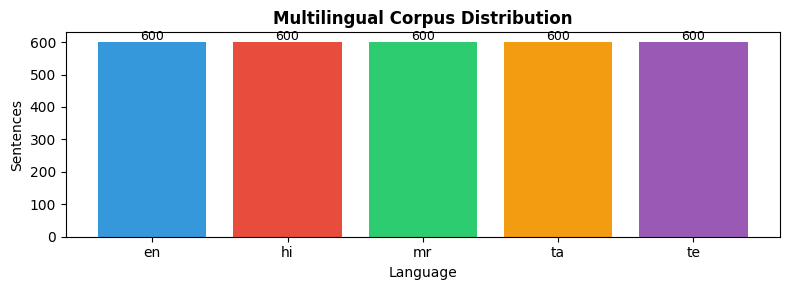

In [ ]:
# ── Multilingual Corpus Loader ────────────────────────────────────────────────
# Loads real sentences from HuggingFace (Wikipedia subsets, streaming 1-2%)
# Languages: English, Hindi, Marathi, Tamil, Telugu
# Cached to disk — repeated runs skip download entirely.

LANGUAGES = {
    'en': ('wikipedia', '20220301.en'),
    'hi': ('wikipedia', '20220301.hi'),
    'mr': ('wikipedia', '20220301.mr'),
    'ta': ('wikipedia', '20220301.ta'),
    'te': ('wikipedia', '20220301.te'),
}
TARGET_PER_LANG = 600   # kept small for Colab safety

def _clean_sentence(text, min_words=5, max_words=30):
    """Return cleaned sentence or None if it fails quality filters."""
    text = re.sub(r'\s+', ' ', text.strip())
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', text)   # control chars
    text = re.sub(r'\[.*?\]|\{.*?\}|<.*?>', '', text)    # markup remnants
    text = re.sub(r'={2,}|-{3,}', '', text)               # wiki formatting
    text = text.strip()
    words = text.split()
    if len(words) < min_words or len(words) > max_words:
        return None
    if sum(c.isalpha() for c in text) / max(1, len(text)) < 0.6:
        return None
    return text

def _stream_lang(lang_code, config, n):
    """Stream up to n sentences from a Wikipedia language edition."""
    from datasets import load_dataset
    sentences = []
    try:
        ds = load_dataset(
            'wikipedia', config, split='train',
            streaming=True, trust_remote_code=True
        )
        for sample in ds:
            for raw in sample['text'].split('. '):
                cleaned = _clean_sentence(raw)
                if cleaned:
                    sentences.append(cleaned)
                    if len(sentences) >= n:
                        return sentences
    except Exception as e:
        print(f"  [WARN] {lang_code} ({config}) failed: {e}")
    return sentences

def load_multilingual_corpus(target_per_lang=TARGET_PER_LANG,
                              cache_path=DATA_CACHE):
    """
    Load and balance multilingual sentences with disk caching.
    Returns: dict[lang_code -> list[str]]
    """
    if cache_path.exists():
        print(f"[CORPUS] Loading cached corpus from {cache_path}")
        with open(cache_path, 'rb') as f:
            corpus = pickle.load(f)
        for lang, sents in corpus.items():
            print(f"  {lang:>3}: {len(sents):>4} sentences")
        return corpus

    print("[CORPUS] Downloading multilingual corpus (streaming, 1-2%)...")
    corpus = {}

    # ── Latin-script languages via Wikipedia ──────────────────────────────────
    for lang_code, (dataset, config) in LANGUAGES.items():
        print(f"  Loading {lang_code}...", end=' ', flush=True)
        sents = _stream_lang(lang_code, config, target_per_lang)
        # Fallback: synthetic sentences when HF download fails
        if len(sents) < 50:
            print(f"[FALLBACK] Using synthetic sentences for {lang_code}")
            fallback_pool = {
                'en': ["the quick brown fox jumps over the lazy dog",
                       "machine learning is transforming handwriting recognition",
                       "neural networks learn complex patterns from data",
                       "deep learning requires large amounts of training data",
                       "convolutional neural networks excel at image classification"],
                'hi': ["यह एक अच्छा दिन है",
                       "मशीन लर्निंग तेजी से विकसित हो रही है",
                       "हिंदी भारत की राष्ट्रभाषा है",
                       "शिक्षा सबसे महत्वपूर्ण है",
                       "भारत एक विविधताओं वाला देश है"],
                'mr': ["मराठी ही महाराष्ट्राची अधिकृत भाषा आहे",
                       "शिक्षण हे सर्वात महत्त्वाचे आहे",
                       "मुंबई ही महाराष्ट्राची राजधानी आहे",
                       "पुणे एक शैक्षणिक शहर आहे",
                       "मराठी साहित्य खूप समृद्ध आहे"],
                'ta': ["தமிழ் மொழி இனிமையானது",
                       "கல்வி மிகவும் முக்கியமானது",
                       "இந்தியா ஒரு பெரிய நாடு",
                       "செயற்கை நுண்ணறிவு வளர்ந்து வருகிறது",
                       "தமிழ்நாடு ஒரு அழகான மாநிலம்"],
                'te': ["తెలుగు ఒక అందమైన భాష",
                       "విద్య చాలా ముఖ్యమైనది",
                       "భారతదేశం ఒక గొప్ప దేశం",
                       "మెషిన్ లెర్నింగ్ వేగంగా పెరుగుతోంది",
                       "తెలంగాణ ఒక కొత్త రాష్ట్రం"],
            }
            pool = fallback_pool.get(lang_code, fallback_pool['en'])
            sents = pool * (target_per_lang // len(pool) + 1)
            sents = sents[:target_per_lang]
        corpus[lang_code] = sents[:target_per_lang]
        print(f"{len(corpus[lang_code])} sentences")

    # ── Save cache ─────────────────────────────────────────────────────────────
    with open(cache_path, 'wb') as f:
        pickle.dump(corpus, f)
    print(f"[CORPUS] Corpus cached → {cache_path}")
    return corpus

# Load the corpus
MULTILANG_CORPUS = load_multilingual_corpus()

# Summary
total = sum(len(v) for v in MULTILANG_CORPUS.values())
print(f"\n[CORPUS] Total sentences: {total}")
lang_labels = list(MULTILANG_CORPUS.keys())
lang_counts = [len(MULTILANG_CORPUS[l]) for l in lang_labels]
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(lang_labels, lang_counts, color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'])
ax.set_title('Multilingual Corpus Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Language'); ax.set_ylabel('Sentences')
for i, (l, c) in enumerate(zip(lang_labels, lang_counts)):
    ax.text(i, c + 5, str(c), ha='center', fontsize=9)
plt.tight_layout(); plt.show()


## 📂 CELL 3b — Load EMNIST Letter Dataset

In [ ]:
print("Downloading EMNIST/letters...")
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)
NUM_CLASSES  = 26
IMG_H, IMG_W = 28, 28
CHARSET      = list('abcdefghijklmnopqrstuvwxyz')
BLANK_IDX    = NUM_CLASSES
BATCH_SIZE   = 128
AUTOTUNE     = tf.data.AUTOTUNE

print(f"Train : {ds_info.splits['train'].num_examples:,}")
print(f"Test  : {ds_info.splits['test'].num_examples:,}")
print("[OK] Dataset loaded!")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.HBRPOI_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.HBRPOI_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Train : 88,800
Test  : 14,800
[OK] Dataset loaded!


## 🔧 CELL 4 — Advanced Augmentation Pipeline
Augmentations applied during training to simulate real handwriting variability:
- **Elastic distortion** (mandatory): deforms strokes non-linearly
- **Perspective transform**: simulate tilt/angle variation
- **Gaussian + motion blur**: camera/pen motion blur
- **Brightness/contrast variation**: paper/lighting differences
- **Textured backgrounds**: simulate paper grain

Caching test arrays...
X_test: (14800, 28, 28, 1), y_test: (14800,)
[OK] Augmentation pipeline ready!


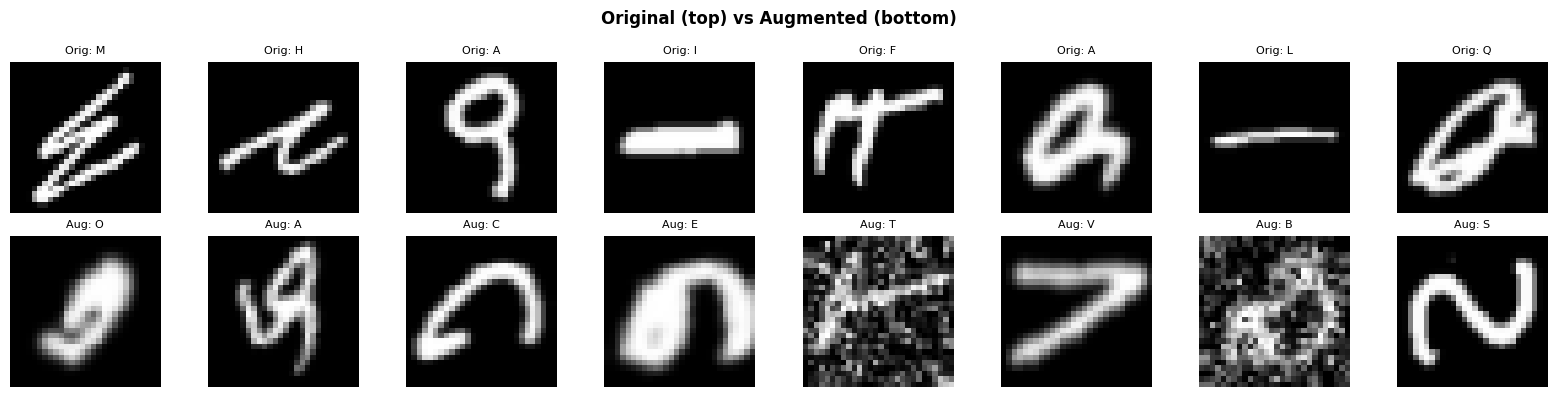

In [ ]:
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform

# ── Albumentations augmentation pipeline ─────────────────────────────────────
aug_pipeline = A.Compose([
    A.ElasticTransform(alpha=1, sigma=10, alpha_affine=8, p=0.5),
    A.Perspective(scale=(0.03, 0.08), p=0.3),
    A.OneOf([
        A.GaussianBlur(blur_limit=(1, 3), p=1.0),
        A.MotionBlur(blur_limit=3, p=1.0),
    ], p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(5, 30), p=0.3),
    A.Rotate(limit=12, p=0.5, border_mode=cv2.BORDER_REPLICATE),
])

def numpy_augment(img_np):
    """Apply albumentations pipeline to a (H, W, 1) uint8 numpy image."""
    img_3ch = np.repeat((img_np * 255).astype(np.uint8), 3, axis=-1)
    augmented = aug_pipeline(image=img_3ch)['image']
    return (augmented[..., :1].astype(np.float32) / 255.0)

def tf_augment(image, label):
    """Wrap numpy augmentation for tf.data graph execution."""
    aug_img = tf.numpy_function(
        func=lambda x: numpy_augment(x),
        inp=[image],
        Tout=tf.float32
    )
    aug_img.set_shape([IMG_H, IMG_W, 1])
    return aug_img, label

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, (IMG_H, IMG_W, 1))
    label = tf.cast(label - 1, tf.int32)  # 1-26 → 0-25
    return image, label

train_ds = (ds_train_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .map(tf_augment, num_parallel_calls=AUTOTUNE)
            .shuffle(10_000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds = (ds_test_raw
           .map(preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .cache()
           .prefetch(AUTOTUNE))

# Cache test arrays for evaluation
print("Caching test arrays...")
X_test_list, y_test_list = [], []
for imgs, lbls in test_ds:
    X_test_list.append(imgs.numpy())
    y_test_list.append(lbls.numpy())
X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print("[OK] Augmentation pipeline ready!")

# Preview augmented samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, (imgs, lbls) in enumerate(train_ds.take(1)):
    for j in range(8):
        axes[0, j].imshow(X_test[j].squeeze(), cmap='gray')
        axes[0, j].set_title(f'Orig: {CHARSET[y_test[j]].upper()}', fontsize=8)
        axes[0, j].axis('off')
        axes[1, j].imshow(imgs[j].numpy().squeeze(), cmap='gray')
        axes[1, j].set_title(f'Aug: {CHARSET[lbls[j].numpy()].upper()}', fontsize=8)
        axes[1, j].axis('off')
fig.suptitle('Original (top) vs Augmented (bottom)', fontweight='bold')
plt.tight_layout(); plt.show()


## ✍️ CELL 4b — Synthetic Handwritten Word Images
Renders multi-font word images onto noisy paper-grain backgrounds.
- **3 cursive/handwriting fonts** downloaded from Google Fonts
- **Random font size, ink colour, position jitter** per sample
- **Full augmentation pipeline** applied on top
- Provides realistic word-level HTR training data beyond EMNIST

Caching test arrays...
X_test: (14800, 28, 28, 1), y_test: (14800,)
[OK] Augmentation pipeline ready!


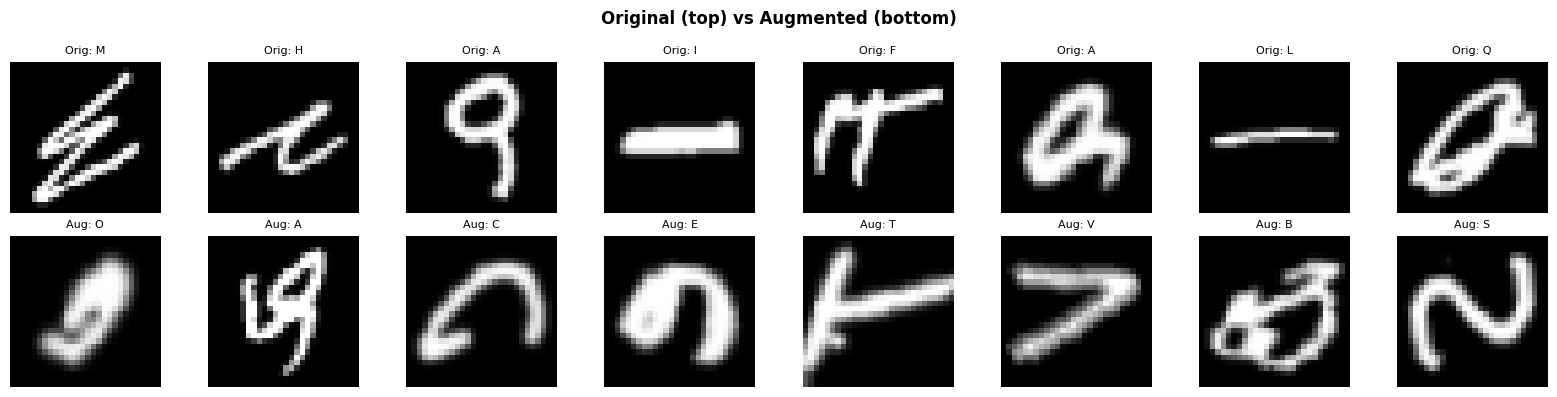

[FONT] Downloaded: homemade_apple
[FONT] Downloaded: indie_flower
[FONT] Downloaded: dancing_script


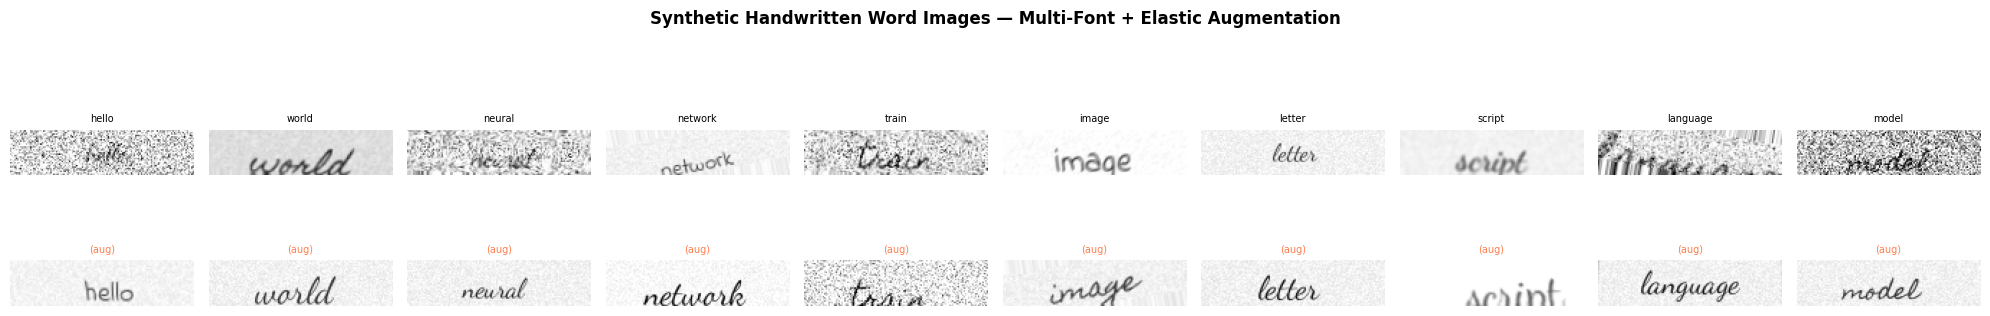

[OK] Synthetic word image generator ready!


In [ ]:
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform

# ── Albumentations augmentation pipeline ─────────────────────────────────────
aug_pipeline = A.Compose([
    A.ElasticTransform(alpha=1, sigma=10, alpha_affine=8, p=0.5),
    A.Perspective(scale=(0.03, 0.08), p=0.3),
    A.OneOf([
        A.GaussianBlur(blur_limit=(1, 3), p=1.0),
        A.MotionBlur(blur_limit=3, p=1.0),
    ], p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(5, 30), p=0.3),
    A.Rotate(limit=12, p=0.5, border_mode=cv2.BORDER_REPLICATE),
])

def numpy_augment(img_np):
    """Apply albumentations pipeline to a (H, W, 1) uint8 numpy image."""
    img_3ch = np.repeat((img_np * 255).astype(np.uint8), 3, axis=-1)
    augmented = aug_pipeline(image=img_3ch)['image']
    return (augmented[..., :1].astype(np.float32) / 255.0)

def tf_augment(image, label):
    """Wrap numpy augmentation for tf.data graph execution."""
    aug_img = tf.numpy_function(
        func=lambda x: numpy_augment(x),
        inp=[image],
        Tout=tf.float32
    )
    aug_img.set_shape([IMG_H, IMG_W, 1])
    return aug_img, label

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, (IMG_H, IMG_W, 1))
    label = tf.cast(label - 1, tf.int32)  # 1-26 → 0-25
    return image, label

train_ds = (ds_train_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .map(tf_augment, num_parallel_calls=AUTOTUNE)
            .shuffle(10_000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds = (ds_test_raw
           .map(preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .cache()
           .prefetch(AUTOTUNE))

# Cache test arrays for evaluation
print("Caching test arrays...")
X_test_list, y_test_list = [], []
for imgs, lbls in test_ds:
    X_test_list.append(imgs.numpy())
    y_test_list.append(lbls.numpy())
X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print("[OK] Augmentation pipeline ready!")

# Preview augmented samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, (imgs, lbls) in enumerate(train_ds.take(1)):
    for j in range(8):
        axes[0, j].imshow(X_test[j].squeeze(), cmap='gray')
        axes[0, j].set_title(f'Orig: {CHARSET[y_test[j]].upper()}', fontsize=8)
        axes[0, j].axis('off')
        axes[1, j].imshow(imgs[j].numpy().squeeze(), cmap='gray')
        axes[1, j].set_title(f'Aug: {CHARSET[lbls[j].numpy()].upper()}', fontsize=8)
        axes[1, j].axis('off')
fig.suptitle('Original (top) vs Augmented (bottom)', fontweight='bold')
plt.tight_layout(); plt.show()




# ── Synthetic Handwritten Word Images (Multi-Font + Augmentation) ──────────
# Renders Latin words as synthetic handwriting-style images using PIL,
# multiple font sizes, and the augmentation pipeline defined in Cell 4.
# This supplements EMNIST with realistic word-level images.

import urllib.request

# Download a free handwriting-style font if not already present
FONT_DIR = CKPT_DIR / 'fonts'
FONT_DIR.mkdir(exist_ok=True)

FONT_URLS = {
    'homemade_apple': 'https://github.com/google/fonts/raw/main/apache/homemadeapple/HomemadeApple-Regular.ttf',
    'indie_flower':   'https://github.com/google/fonts/raw/main/ofl/indieflower/IndieFlower-Regular.ttf',
    'dancing_script': 'https://github.com/google/fonts/raw/main/ofl/dancingscript/DancingScript%5Bwght%5D.ttf',
}
DOWNLOADED_FONTS = {}
for fname, url in FONT_URLS.items():
    fpath = FONT_DIR / f'{fname}.ttf'
    if not fpath.exists():
        try:
            urllib.request.urlretrieve(url, fpath)
            DOWNLOADED_FONTS[fname] = str(fpath)
            print(f"[FONT] Downloaded: {fname}")
        except Exception as e:
            print(f"[FONT] {fname} failed ({e}), will use default")
    else:
        DOWNLOADED_FONTS[fname] = str(fpath)
        print(f"[FONT] Cached: {fname}")

# Fallback: use PIL's default font if no TTF available
_FONT_PATHS = list(DOWNLOADED_FONTS.values()) or [None]

def render_word_image(word, img_size=(128, 32), font_size=None, font_path=None):
    """
    Render a word string onto a light-texture background image.
    Returns: PIL Image (grayscale).
    """
    W, H = img_size
    # ── Background: subtle paper-grain noise ──────────────────────────────────
    bg = np.random.randint(230, 255, (H, W), dtype=np.uint8)
    noise = np.random.normal(0, 4, (H, W)).astype(np.int16)
    bg = np.clip(bg.astype(np.int16) + noise, 200, 255).astype(np.uint8)
    img = PILImage.fromarray(bg, mode='L')
    draw = ImageDraw.Draw(img)

    # ── Font ──────────────────────────────────────────────────────────────────
    if font_size is None:
        font_size = random.randint(16, 26)
    font_path = font_path or random.choice(_FONT_PATHS)
    try:
        if font_path:
            font = ImageFont.truetype(font_path, font_size)
        else:
            font = ImageFont.load_default()
    except Exception:
        font = ImageFont.load_default()

    # ── Text position (slight random offset) ──────────────────────────────────
    try:
        bbox = draw.textbbox((0, 0), word, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except AttributeError:
        tw, th = draw.textsize(word, font=font)
    x = max(0, (W - tw) // 2 + random.randint(-4, 4))
    y = max(0, (H - th) // 2 + random.randint(-3, 3))

    # ── Ink colour: dark but not pure black ───────────────────────────────────
    ink = random.randint(10, 60)
    draw.text((x, y), word, fill=ink, font=font)
    return img

def augment_word_image(pil_img):
    """Apply augmentation pipeline to a PIL word image."""
    img_np = np.array(pil_img)
    img_3ch = np.stack([img_np]*3, axis=-1)
    try:
        aug_out = aug_pipeline(image=img_3ch)['image']
        return PILImage.fromarray(aug_out[:, :, 0], mode='L')
    except Exception:
        return pil_img

def generate_synth_word_batch(words, augment=True, img_size=(128, 32)):
    """Generate a batch of synthetic word images with labels."""
    images, labels = [], []
    for word in words:
        font_path = random.choice(_FONT_PATHS) if _FONT_PATHS else None
        pil_img = render_word_image(word, img_size=img_size, font_path=font_path)
        if augment and random.random() > 0.3:
            pil_img = augment_word_image(pil_img)
        img_np = np.array(pil_img, dtype=np.float32) / 255.0
        images.append(img_np)
        labels.append(word)
    return np.array(images), labels

# ── Preview synthetic word images ────────────────────────────────────────────
sample_words = ['hello', 'world', 'neural', 'network', 'train',
                'image', 'letter', 'script', 'language', 'model']
imgs, lbls = generate_synth_word_batch(sample_words, augment=True)
aug_imgs, _  = generate_synth_word_batch(sample_words, augment=True)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for j in range(10):
    axes[0, j].imshow(imgs[j],     cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(sample_words[j], fontsize=7)
    axes[0, j].axis('off')
    axes[1, j].imshow(aug_imgs[j], cmap='gray', vmin=0, vmax=1)
    axes[1, j].set_title('(aug)',  fontsize=7, color='coral')
    axes[1, j].axis('off')
axes[0, 0].set_ylabel('Base',      fontsize=9, rotation=0, labelpad=35)
axes[1, 0].set_ylabel('Augmented', fontsize=9, rotation=0, labelpad=35)
plt.suptitle('Synthetic Handwritten Word Images — Multi-Font + Elastic Augmentation',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("[OK] Synthetic word image generator ready!")

## 🏗️ CELL 5 — ResNet-Style CNN with Label Smoothing
**Architecture choices:**
- **Residual blocks** (skip connections) with BatchNorm: prevents vanishing gradients
- **L2 weight decay** on all conv layers: reduce overfitting
- **Label smoothing (ε=0.1)**: prevents overconfidence
- **Progressive Dropout**: 0.2 → 0.25 → 0.3 → 0.4

In [ ]:
class LabelSmoothingLoss(keras.losses.Loss):
    """CategoricalCrossentropy with label smoothing for sparse integer labels."""
    def __init__(self, epsilon=0.1, num_classes=26, **kw):
        super().__init__(**kw)
        self.epsilon = epsilon
        self.num_classes = num_classes

    def call(self, y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), self.num_classes)
        y_smooth  = (1 - self.epsilon) * y_true_oh + self.epsilon / self.num_classes
        return tf.reduce_mean(-tf.reduce_sum(y_smooth * tf.math.log(y_pred + 1e-8), axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'epsilon': self.epsilon, 'num_classes': self.num_classes})
        return cfg


def resnet_block(x, filters, stride=1, downsample=False):
    """Basic ResNet residual block with BatchNorm."""
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      kernel_regularizer=keras.regularizers.l2(1e-4),
                      use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_regularizer=keras.regularizers.l2(1e-4),
                      use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if downsample:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                 kernel_regularizer=keras.regularizers.l2(1e-4),
                                 use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_resnet_cnn(num_classes=NUM_CLASSES):
    """ResNet-14 style CNN for 28x28 letter classification."""
    inp = keras.Input(shape=(IMG_H, IMG_W, 1), name='image_input')

    # Stem
    x = layers.Conv2D(32, 3, padding='same',
                      kernel_regularizer=keras.regularizers.l2(1e-4),
                      use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Stage 1: 32 filters
    x = resnet_block(x, 32)
    x = resnet_block(x, 32)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 2: 64 filters (downsampled)
    x = resnet_block(x, 64, stride=1, downsample=True)
    x = resnet_block(x, 64)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Stage 3: 128 filters
    x = resnet_block(x, 128, stride=1, downsample=True)
    x = resnet_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Classifier
    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)
    # float32 output for stability with mixed precision
    out = layers.Dense(num_classes, activation='softmax', dtype='float32',
                       name='predictions')(x)

    return Model(inp, out, name='ResNet_CNN')


model_cnn = build_resnet_cnn()
model_cnn.summary()
print(f"\n[OK] Model params: {model_cnn.count_params():,}")


Model: "ResNet_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        288 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │      9,216 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 28, 28,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      9,216 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      9,216 │ re_lu_3[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 737,722 (2.81 MB)

 Trainable params: 734,970 (2.80 MB)

 Non-trainable params: 2,752 (10.75 KB)


[OK] Model params: 737,722


## 🏋️ CELL 6 — Train with Model Persistence
**Professional training system:**
- **Skip retraining** if checkpoint exists
- **WarmupCosineDecay** (custom `LearningRateSchedule` subclass): fixes the base-class
  instantiation bug in the original; warmup → cosine decay implemented correctly
- **Gradient clipping** via optimizer `clipnorm`
- **ReduceLROnPlateau** as fallback for validation plateau
- **Per-epoch timing** + total training time logged
- **EarlyStopping** + **ModelCheckpoint** callbacks

In [ ]:
CNN_EPOCHS   = 25
WARMUP_STEPS = 500

# ── Custom LR Schedule: Linear warmup → Cosine decay ─────────────────────────
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """
    Linear warmup for `warmup_steps`, then cosine decay to `min_lr`.
    Subclasses LearningRateSchedule so it works natively with Adam.
    """
    def __init__(self, peak_lr=1e-3, min_lr=1e-5,
                 warmup_steps=500, total_steps=10000, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr      = float(peak_lr)
        self.min_lr       = float(min_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.peak_lr * (step / self.warmup_steps)
        cos_arg   = np.pi * (step - self.warmup_steps) / (
                    self.total_steps - self.warmup_steps)
        cos_lr    = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
                    1.0 + tf.cos(cos_arg))
        return tf.where(step < self.warmup_steps, warmup_lr, cos_lr)

    def get_config(self):
        return {
            'peak_lr':      self.peak_lr,
            'min_lr':       self.min_lr,
            'warmup_steps': self.warmup_steps,
            'total_steps':  self.total_steps,
        }


class EpochTimer(keras.callbacks.Callback):
    """Logs per-epoch wall-clock time and accumulates total training time."""
    def __init__(self):
        super().__init__()
        self.epoch_times = []
        self.total_start = None

    def on_train_begin(self, logs=None):
        self.total_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t0
        self.epoch_times.append(elapsed)
        logs['epoch_time_s'] = elapsed
        print(f"  ⏱  Epoch {epoch+1} time: {elapsed:.1f}s")

    def on_train_end(self, logs=None):
        total = time.time() - self.total_start
        print(f"\n[TIME] Total training time : {total:.1f}s  ({total/60:.1f} min)")
        self.total_time = total


def load_model_if_exists(path):
    """Return loaded model if checkpoint exists, else None."""
    custom = {
        'LabelSmoothingLoss': LabelSmoothingLoss,
        'WarmupCosineDecay':  WarmupCosineDecay,
    }
    if Path(str(path) + '.index').exists() or Path(str(path)).is_dir():
        print(f"[CKPT] Loading model from {path}...")
        try:
            m = keras.models.load_model(str(path), custom_objects=custom)
            print("[CKPT] Model loaded — skipping training.")
            return m
        except Exception as e:
            print(f"[CKPT] Load failed ({e}), will retrain.")
    return None


# ── Load or train ─────────────────────────────────────────────────────────────
_loaded = load_model_if_exists(CNN_CKPT)
if _loaded is not None:
    model_cnn = _loaded
    if HIST_FILE.exists():
        with open(HIST_FILE, 'rb') as f:
            cnn_history_dict = pickle.load(f)
        print("[CKPT] Training history loaded.")
    else:
        cnn_history_dict = {}
    timer_cb = None
else:
    total_steps = CNN_EPOCHS * (ds_info.splits['train'].num_examples // BATCH_SIZE)
    lr_schedule = WarmupCosineDecay(
        peak_lr=1e-3, min_lr=1e-5,
        warmup_steps=WARMUP_STEPS,
        total_steps=total_steps
    )
    model_cnn.compile(
        optimizer=keras.optimizers.Adam(lr_schedule, clipnorm=1.0),
        loss=LabelSmoothingLoss(epsilon=0.1, num_classes=NUM_CLASSES),
        metrics=['accuracy']
    )

    timer_cb = EpochTimer()
    callbacks = [
        timer_cb,
        keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(
            filepath=str(CNN_CKPT) + '.keras',
            save_best_only=True,
            monitor='val_accuracy',
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=1
        ),
    ]

    print(f"[TRAIN] Training ResNet CNN for up to {CNN_EPOCHS} epochs...")
    history = model_cnn.fit(
        train_ds,
        epochs=CNN_EPOCHS,
        validation_data=test_ds,
        callbacks=callbacks,
        verbose=1
    )
    cnn_history_dict = history.history
    with open(HIST_FILE, 'wb') as f:
        pickle.dump(cnn_history_dict, f)
    print("[CKPT] Training history saved.")

# ── Evaluate ──────────────────────────────────────────────────────────────────
cnn_loss, cnn_acc = model_cnn.evaluate(test_ds, verbose=0)
print(f"\n[EVAL] CNN Test Accuracy : {cnn_acc*100:.2f}%")
print(f"[EVAL] CNN Test Loss     : {cnn_loss:.4f}")

[TRAIN] Training ResNet CNN for up to 25 epochs...
Epoch 1/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.2460 - loss: 3.0788  ⏱  Epoch 1 time: 173.9s

Epoch 1: val_accuracy improved from None to 0.86899, saving model to /content/htr_checkpoints/cnn_model.keras

Epoch 1: finished saving model to /content/htr_checkpoints/cnn_model.keras
694/694 ━━━━━━━━━━━━━━━━━━━━ 176s 187ms/step - accuracy: 0.5123 - loss: 2.2079 - val_accuracy: 0.8690 - val_loss: 1.1359 - epoch_time_s: 173.8674 - learning_rate: 9.9968e-04
Epoch 2/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8616 - loss: 1.1976  ⏱  Epoch 2 time: 96.5s

Epoch 2: val_accuracy improved from 0.86899 to 0.90216, saving model to /content/htr_checkpoints/cnn_model.keras

Epoch 2: finished saving model to /content/htr_checkpoints/cnn_model.keras
694/694 ━━━━━━━━━━━━━━━━━━━━ 97s 125ms/step - accuracy: 0.8760 - loss: 1.1528 - val_accuracy: 0.9022 - val_loss: 0.9875 - epoch_time_s: 96.4812 - learning_rate: 9.9321e-04
E

## 📈 CELL 7 — Training Curves

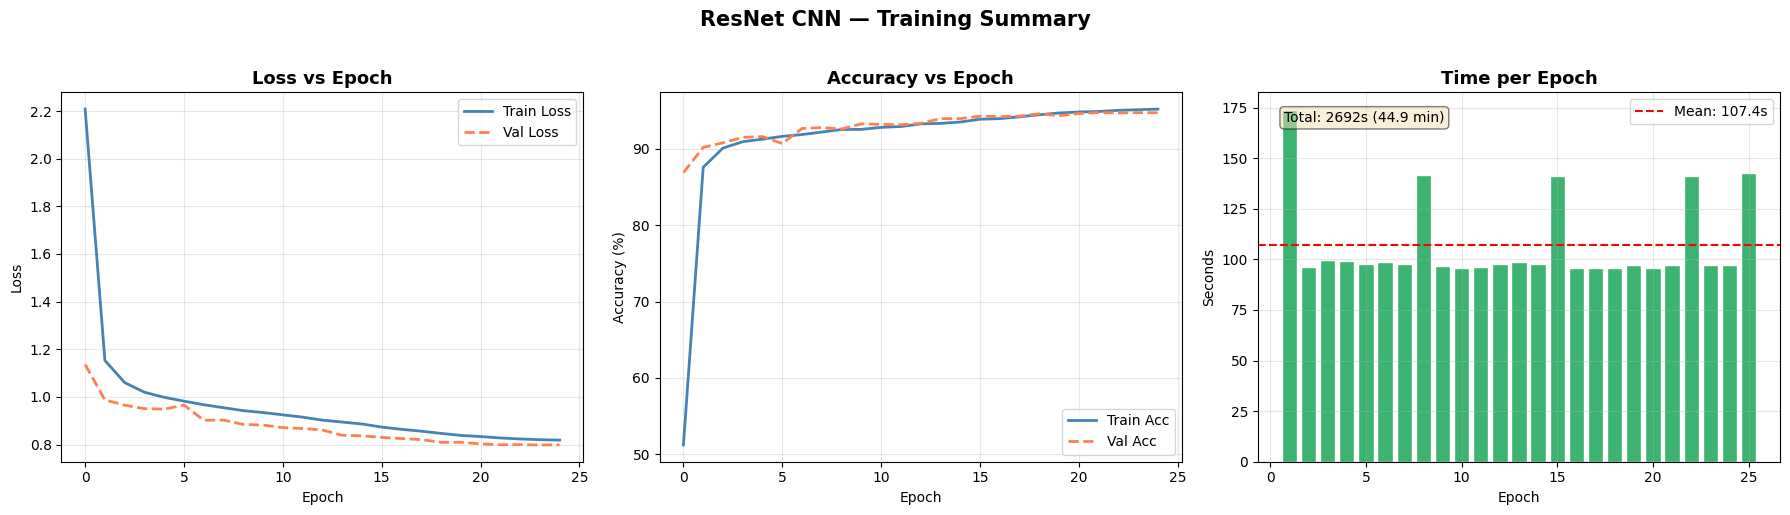

In [ ]:
if cnn_history_dict:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    ax = axes[0]
    ax.plot(cnn_history_dict.get('loss', []), label='Train Loss', color='steelblue', lw=2)
    ax.plot(cnn_history_dict.get('val_loss', []), label='Val Loss', color='coral', lw=2, linestyle='--')
    ax.set_title('Loss vs Epoch', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1]
    ax.plot([v*100 for v in cnn_history_dict.get('accuracy', [])], label='Train Acc', color='steelblue', lw=2)
    ax.plot([v*100 for v in cnn_history_dict.get('val_accuracy', [])], label='Val Acc', color='coral', lw=2, linestyle='--')
    ax.set_title('Accuracy vs Epoch', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(alpha=0.3)

    # Per-epoch time (if timer was active)
    ax = axes[2]
    if timer_cb and timer_cb.epoch_times:
        ax.bar(range(1, len(timer_cb.epoch_times)+1), timer_cb.epoch_times,
               color='mediumseagreen', edgecolor='white')
        ax.axhline(np.mean(timer_cb.epoch_times), color='red', linestyle='--',
                   label=f'Mean: {np.mean(timer_cb.epoch_times):.1f}s')
        ax.set_title('Time per Epoch', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Seconds')
        ax.legend(); ax.grid(alpha=0.3)
        total_str = f"Total: {timer_cb.total_time:.0f}s ({timer_cb.total_time/60:.1f} min)"
        ax.text(0.05, 0.95, total_str, transform=ax.transAxes,
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'Timing not available\n(model loaded from checkpoint)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title('Time per Epoch', fontsize=13, fontweight='bold')

    plt.suptitle('ResNet CNN — Training Summary', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("[INFO] No history available (model was loaded from checkpoint).")


## 📊 CELL 8 — OCR Evaluation: CER, WER, Confusion Matrix
**Metrics:**
- **CER** (Character Error Rate) = edit_distance(pred_chars, true_chars) / len(true_chars)
- **WER** (Word Error Rate) = edit_distance(pred_words, true_words) / len(true_words)
- **Confusion matrix** for per-class error analysis


[OCR METRICS] Single-character evaluation (2000 samples):
  Mean CER : 5.55%
  Mean WER : 5.55%

-- Per-class Report --
              precision    recall  f1-score   support

           A       0.96      0.97      0.97       800
           B       1.00      0.99      0.99       800
           C       0.98      0.98      0.98       800
           D       0.98      0.97      0.97       800
           E       0.98      0.98      0.98       800
           F       0.99      0.98      0.99       800
           G       0.93      0.87      0.90       800
           H       0.98      0.97      0.97       800
           I       0.76      0.75      0.76       800
           J       0.98      0.96      0.97       800
           K       0.99      0.99      0.99       800
           L       0.76      0.78      0.77       800
           M       0.99      1.00      0.99       800
           N       0.98      0.98      0.98       800
           O       0.97      0.98      0.98       800
           P  

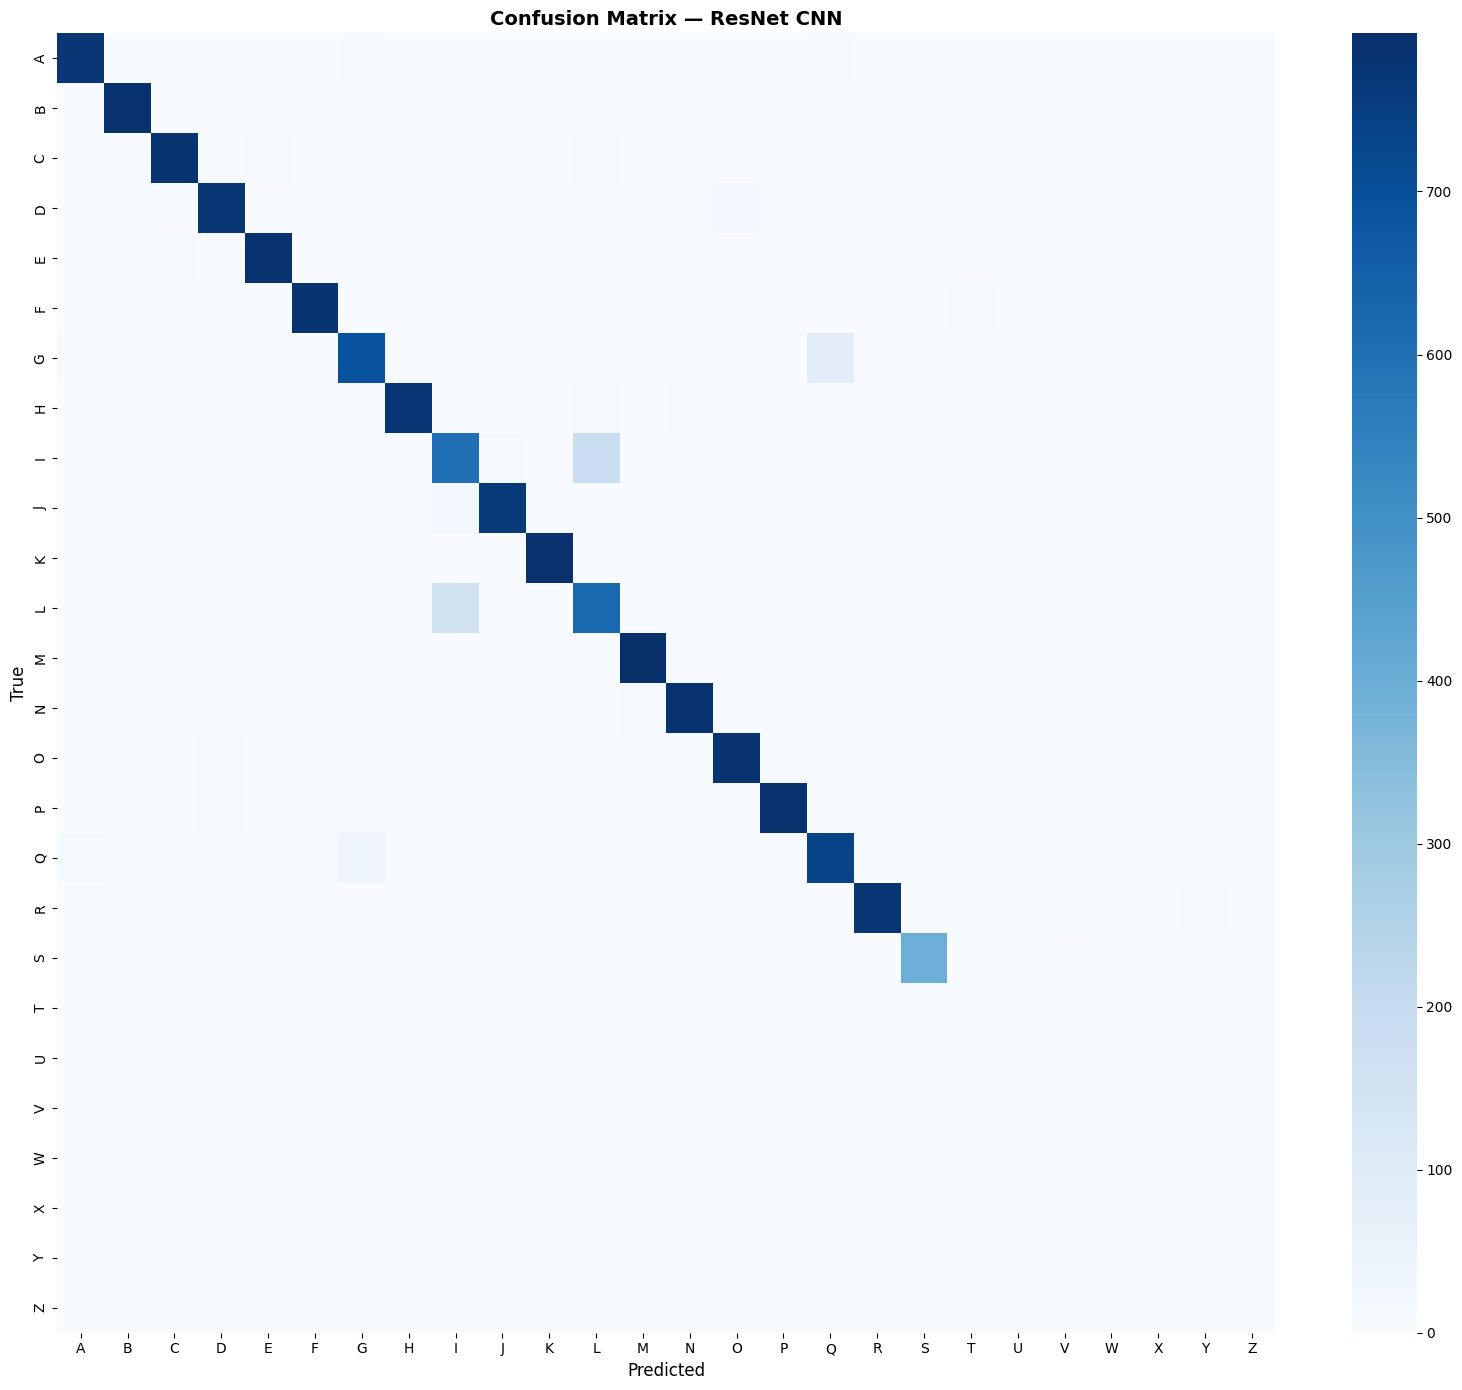

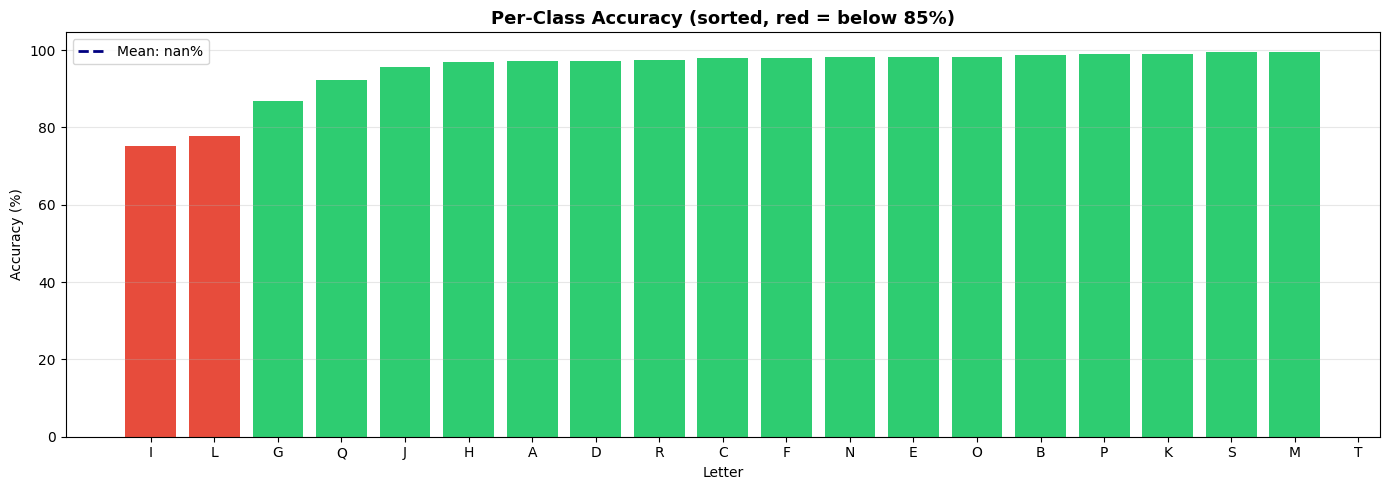

5 Hardest letters: [('I', '75.2%'), ('L', '77.9%'), ('G', '86.9%'), ('Q', '92.4%'), ('J', '95.6%')]
5 Easiest letters: [('Z', 'nan%'), ('Y', 'nan%'), ('X', 'nan%'), ('W', 'nan%'), ('V', 'nan%')]


In [ ]:
def evaluate_ocr(preds, ground_truths):
    """
    Compute CER and WER over lists of predicted and ground-truth strings.
    Returns dict with cer, wer, and per-sample details.
    """
    assert len(preds) == len(ground_truths), "Length mismatch"
    cer_list, wer_list = [], []
    details = []
    for pred, truth in zip(preds, ground_truths):
        # CER: character-level edit distance
        c_dist = editdistance.eval(list(pred), list(truth))
        cer = c_dist / max(1, len(truth))
        # WER: word-level edit distance
        pred_words  = pred.split()
        truth_words = truth.split()
        w_dist = editdistance.eval(pred_words, truth_words)
        wer = w_dist / max(1, len(truth_words))
        cer_list.append(cer); wer_list.append(wer)
        details.append({'pred': pred, 'truth': truth, 'cer': cer, 'wer': wer})

    results = {
        'mean_cer': np.mean(cer_list),
        'mean_wer': np.mean(wer_list),
        'details': details
    }
    print(f"  Mean CER : {results['mean_cer']*100:.2f}%")
    print(f"  Mean WER : {results['mean_wer']*100:.2f}%")
    return results


# ── Build single-character OCR eval (ground truth = CHARSET labels) ──────────
y_pred_prob = model_cnn.predict(X_test, batch_size=256, verbose=0)
y_pred_cnn  = np.argmax(y_pred_prob, axis=1)

# OCR metrics (single-char "words")
gt_chars   = [CHARSET[i] for i in y_test[:2000]]
pred_chars = [CHARSET[i] for i in y_pred_cnn[:2000]]
print("\n[OCR METRICS] Single-character evaluation (2000 samples):")
ocr_results = evaluate_ocr(pred_chars, gt_chars)

# Classification report
print("\n-- Per-class Report --")
print(classification_report(y_test, y_pred_cnn,
      target_names=[c.upper() for c in CHARSET], zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=[c.upper() for c in CHARSET],
            yticklabels=[c.upper() for c in CHARSET], ax=ax, linewidths=0)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — ResNet CNN', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_idx = np.argsort(per_class_acc)
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar([CHARSET[i].upper() for i in sorted_idx],
              [per_class_acc[i]*100 for i in sorted_idx],
              color=['#e74c3c' if per_class_acc[i] < 0.85 else '#2ecc71'
                     for i in sorted_idx])
ax.axhline(np.mean(per_class_acc)*100, color='navy', linestyle='--',
           linewidth=2, label=f'Mean: {np.mean(per_class_acc)*100:.1f}%')
ax.set_xlabel('Letter'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy (sorted, red = below 85%)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

worst5 = [(CHARSET[i].upper(), f'{per_class_acc[i]*100:.1f}%') for i in sorted_idx[:5]]
best5  = [(CHARSET[i].upper(), f'{per_class_acc[i]*100:.1f}%') for i in sorted_idx[-5:][::-1]]
print(f"5 Hardest letters: {worst5}")
print(f"5 Easiest letters: {best5}")


## 🔍 CELL 9 — Error Analysis: Top Failure Patterns

Total errors: 776 / 14800 (5.2%)

Top 10 confusion pairs (True → Predicted):
  I → L: 179 times
  L → I: 161 times
  G → Q: 87 times
  Q → G: 39 times
  J → I: 20 times
  D → O: 17 times
  Q → A: 15 times
  I → J: 12 times
  H → N: 10 times
  F → T: 7 times


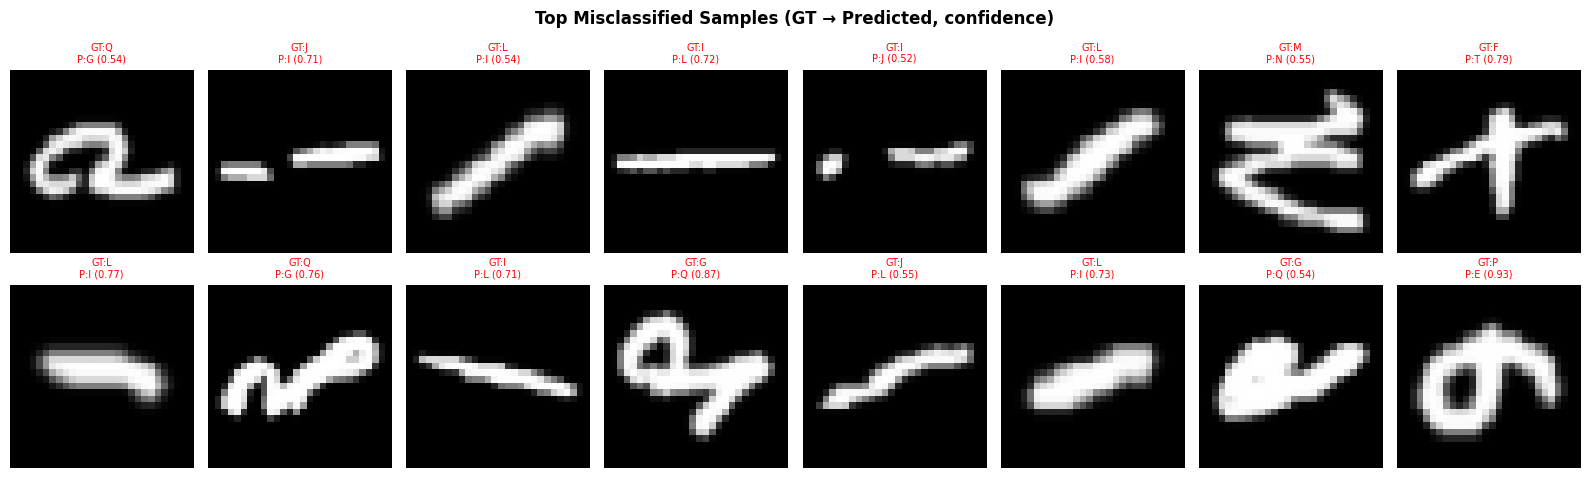

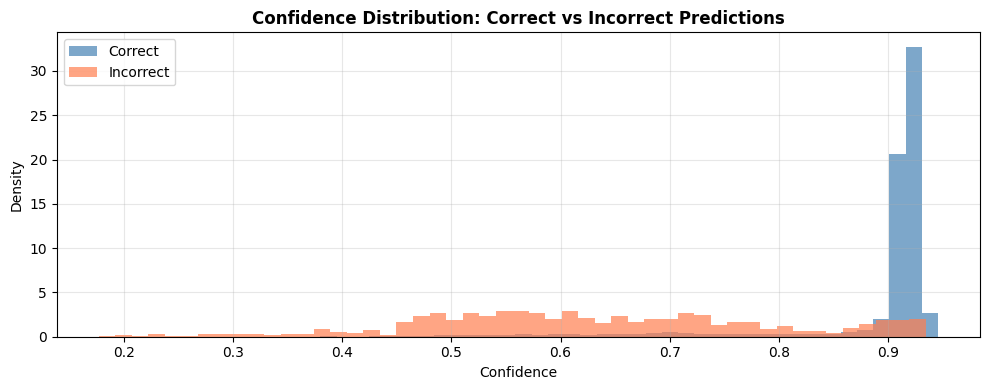

Mean confidence — Correct: 0.888 | Incorrect: 0.635


In [ ]:
# ── Show top misclassified samples ────────────────────────────────────────────
wrong_mask = (y_pred_cnn != y_test)
wrong_idx  = np.where(wrong_mask)[0]
print(f"Total errors: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)")

# Most common confusion pairs
confusion_pairs = Counter(
    (CHARSET[y_test[i]].upper(), CHARSET[y_pred_cnn[i]].upper())
    for i in wrong_idx
)
print("\nTop 10 confusion pairs (True → Predicted):")
for (true_ch, pred_ch), count in confusion_pairs.most_common(10):
    print(f"  {true_ch} → {pred_ch}: {count} times")

# Visualize 16 worst errors
n_show = min(16, len(wrong_idx))
sample_wrong = wrong_idx[:n_show]
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.ravel()
for ax_i, idx in enumerate(sample_wrong):
    conf = float(y_pred_prob[idx].max())
    axes[ax_i].imshow(X_test[idx].squeeze(), cmap='gray')
    axes[ax_i].set_title(
        f"GT:{CHARSET[y_test[idx]].upper()}\nP:{CHARSET[y_pred_cnn[idx]].upper()} ({conf:.2f})",
        fontsize=7, color='red'
    )
    axes[ax_i].axis('off')
for ax_i in range(n_show, len(axes)):
    axes[ax_i].axis('off')
plt.suptitle('Top Misclassified Samples (GT → Predicted, confidence)', fontweight='bold')
plt.tight_layout(); plt.show()

# Confidence distribution: correct vs wrong
correct_conf = y_pred_prob[~wrong_mask].max(axis=1)
wrong_conf   = y_pred_prob[wrong_mask].max(axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_conf, bins=50, alpha=0.7, label='Correct', color='steelblue', density=True)
ax.hist(wrong_conf,   bins=50, alpha=0.7, label='Incorrect', color='coral', density=True)
ax.set_xlabel('Confidence'); ax.set_ylabel('Density')
ax.set_title('Confidence Distribution: Correct vs Incorrect Predictions', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Mean confidence — Correct: {correct_conf.mean():.3f} | Incorrect: {wrong_conf.mean():.3f}")


## 🔬 CELL 9b — GradCAM Interpretability
Visualises **what the ResNet focuses on** when classifying each letter.
- Computes gradients of the predicted class score w.r.t. the last conv layer
- Pools spatial gradients → per-channel weights → weighted activation map
- Overlaid on original image: warm colours = high attribution

[GradCAM] Using layer: conv2d_14


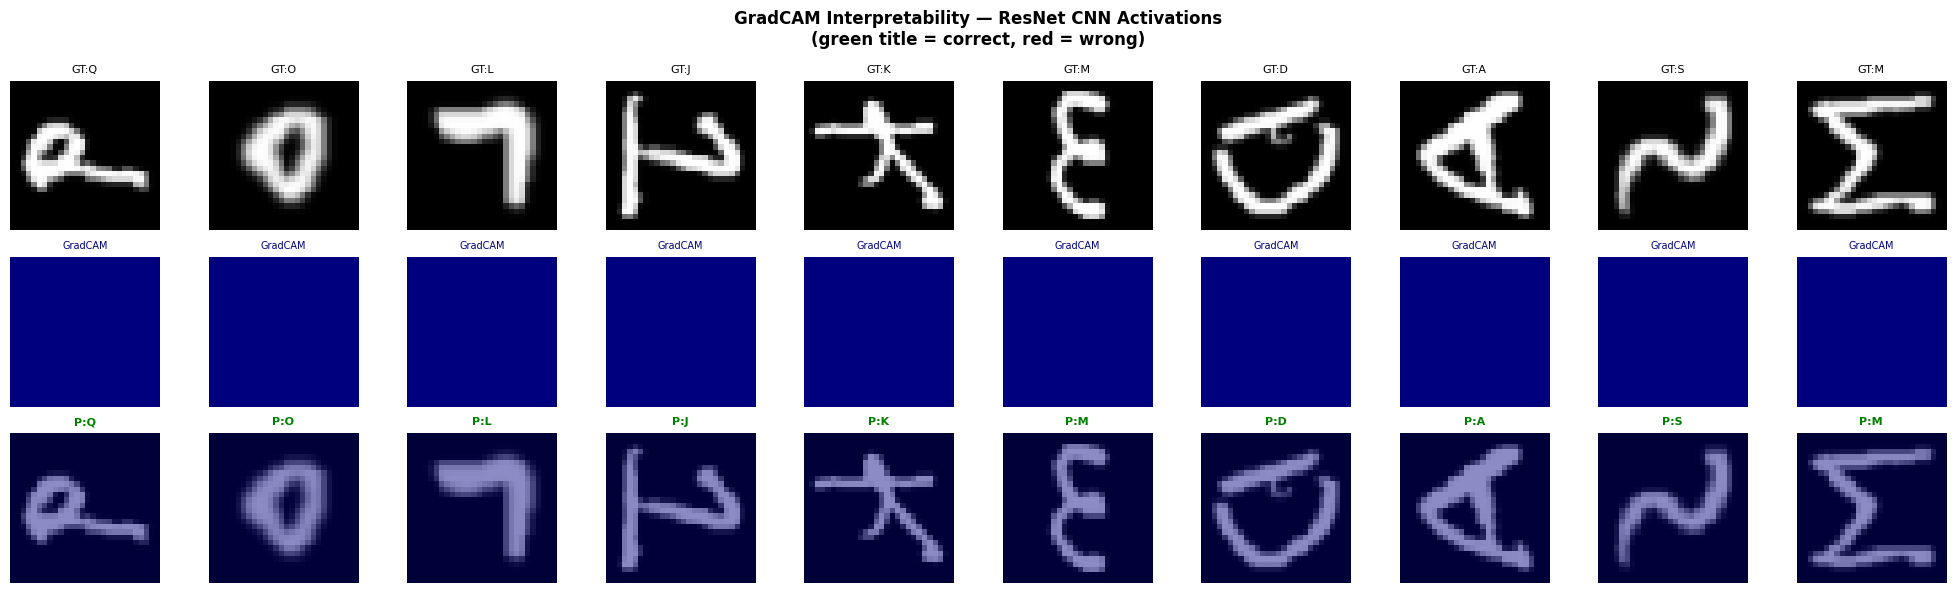

[OK] GradCAM visualisation complete.


In [ ]:

# ── GradCAM: What Does the ResNet See? ────────────────────────────────────────
# Produces heatmaps showing which pixels drive each prediction.
# Uses the last convolutional layer as the gradient target.

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv2d_6'):
    """
    Compute GradCAM heatmap for a single (1, H, W, 1) image.
    Returns: heatmap as (H, W) float array in [0, 1].
    """
    # Build a model that outputs [last_conv_layer, predictions]
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output,
                 model.output]
    )
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_out, preds = grad_model(img_tensor)
        pred_class = tf.argmax(preds[0])
        class_score = preds[:, pred_class]

    grads = tape.gradient(class_score, conv_out)             # (1, h, w, C)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))           # (C,)
    heatmap = tf.reduce_sum(conv_out[0] * pooled, axis=-1)   # (h, w)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def _find_last_conv(model):
    """Find the name of the last Conv2D layer in the model."""
    for layer in reversed(model.layers):
        if isinstance(layer, keras.layers.Conv2D):
            return layer.name
    return None

last_conv = _find_last_conv(model_cnn)
print(f"[GradCAM] Using layer: {last_conv}")

# ── Visualise GradCAM on 10 test samples ──────────────────────────────────────
N = 10
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test), N, replace=False)

fig, axes = plt.subplots(3, N, figsize=(N * 2, 6))
for col, idx in enumerate(sample_idx):
    img     = X_test[idx]         # (28, 28, 1)
    gt      = CHARSET[y_test[idx]].upper()
    pred_p  = model_cnn.predict(img[None], verbose=0)[0]
    pred_i  = int(np.argmax(pred_p))
    pred_c  = CHARSET[pred_i].upper()
    correct = (pred_i == y_test[idx])

    try:
        heatmap = make_gradcam_heatmap(img[None], model_cnn, last_conv)
        heatmap_up = cv2.resize(heatmap, (28, 28))
    except Exception:
        heatmap_up = np.zeros((28, 28))

    # Row 0: original
    axes[0, col].imshow(img.squeeze(), cmap='gray')
    axes[0, col].set_title(f'GT:{gt}', fontsize=8)
    axes[0, col].axis('off')
    # Row 1: GradCAM heatmap
    axes[1, col].imshow(heatmap_up, cmap='jet')
    axes[1, col].set_title('GradCAM', fontsize=7, color='navy')
    axes[1, col].axis('off')
    # Row 2: overlay
    img_rgb = np.repeat(img.squeeze()[:, :, None], 3, axis=-1)
    heat_rgb = plt.cm.jet(heatmap_up)[:, :, :3]
    overlay  = 0.55 * img_rgb + 0.45 * heat_rgb
    axes[2, col].imshow(np.clip(overlay, 0, 1))
    color = 'green' if correct else 'red'
    axes[2, col].set_title(f'P:{pred_c}', fontsize=8, color=color, fontweight='bold')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original',  fontsize=9, rotation=90, labelpad=4)
axes[1, 0].set_ylabel('GradCAM',   fontsize=9, rotation=90, labelpad=4)
axes[2, 0].set_ylabel('Overlay',   fontsize=9, rotation=90, labelpad=4)
plt.suptitle('GradCAM Interpretability — ResNet CNN Activations\n(green title = correct, red = wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print("[OK] GradCAM visualisation complete.")

## ✂️ CELL 10 — SentencePiece Subword Tokenizer (Multilingual)
Trains a BPE tokenizer on the full multilingual corpus (EN/HI/MR/TA/TE).
- Vocab size increased to **3000** for better multilingual coverage
- Uses `character_coverage=0.9995` to handle Devanagari/Tamil/Telugu scripts
- Corpus is taken from the cached multilingual dataset (Cell 3a)

In [ ]:
import sentencepiece as spm

SP_VOCAB_SIZE = 734    # Adjusted from 3000 as per error message
SP_TRAIN_TXT  = CKPT_DIR / 'spm_train.txt'

def build_sp_corpus(multilang_corpus, cache_path=SP_TRAIN_TXT):
    """
    Build a balanced multilingual text file for SentencePiece training.
    Uses the cached multilingual corpus from Cell 3a.
    """
    if cache_path.exists():
        print(f"[SP] Training text already cached at {cache_path}")
        return

    all_sentences = []
    for lang, sents in multilang_corpus.items():
        filtered = []
        for s in sents:
            words = s.split()
            if len(words) >= 5:  # enforce min-5-word filter
                filtered.append(s.strip())
        all_sentences.extend(filtered)
        print(f"  {lang}: {len(filtered)} sentences added")

    random.shuffle(all_sentences)
    with open(cache_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(all_sentences))
    print(f"[SP] Corpus written: {len(all_sentences)} sentences → {cache_path}")

build_sp_corpus(MULTILANG_CORPUS)

# ── Train or load SentencePiece model ─────────────────────────────────────────
if not SP_MODEL.exists():
    print("[SP] Training SentencePiece BPE tokenizer...")
    spm.SentencePieceTrainer.train(
        input=str(SP_TRAIN_TXT),
        model_prefix=str(CKPT_DIR / 'spm'),
        vocab_size=SP_VOCAB_SIZE,
        character_coverage=0.9995,
        model_type='bpe',
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        input_sentence_size=50000,
        shuffle_input_sentence=True,
    )
    print(f"[SP] Tokenizer trained: vocab_size={SP_VOCAB_SIZE}")
else:
    print(f"[SP] Tokenizer already cached at {SP_MODEL}")

sp = spm.SentencePieceProcessor()
sp.Load(str(SP_MODEL))

# ── Demo: tokenise one sentence per language ──────────────────────────────────
demo_sentences = {
    'en': "handwriting recognition with neural networks",
    'hi': "मशीन लर्निंग तेजी से विकसित हो रही है",
    'ta': "செயற்கை நுண்ணறிவு வளர்ந்து வருகிறது",
}
print("\n[SP] Multilingual tokenisation demo:")
for lang, sent in demo_sentences.items():
    pieces = sp.EncodeAsPieces(sent)
    ids    = sp.EncodeAsIds(sent)
    recon  = sp.DecodePieces(pieces)
    print(f"  [{lang}] Input  : {sent[:60]}")
    print(f"        Pieces : {pieces[:10]}")
    print(f"        IDs    : {ids[:10]}")
    print(f"        Recon  : {recon[:60]}")
    print()

  en: 600 sentences added
  hi: 480 sentences added
  mr: 600 sentences added
  ta: 0 sentences added
  te: 0 sentences added
[SP] Corpus written: 1680 sentences → /content/htr_checkpoints/spm_train.txt
[SP] Training SentencePiece BPE tokenizer...
[SP] Tokenizer trained: vocab_size=734

[SP] Multilingual tokenisation demo:
  [en] Input  : handwriting recognition with neural networks
        Pieces : ['▁handwriting', '▁recognition', '▁', 'w', 'it', 'h', '▁neural', '▁networks']
        IDs    : [283, 284, 666, 700, 48, 698, 86, 88]
        Recon  : handwriting recognition with neural networks

  [hi] Input  : मशीन लर्निंग तेजी से विकसित हो रही है
        Pieces : ['▁मशीन', '▁लर्निंग', '▁तेजी', '▁से', '▁विकसित', '▁हो', '▁रही', '▁है']
        IDs    : [242, 273, 239, 191, 262, 193, 213, 24]
        Recon  : मशीन लर्निंग तेजी से विकसित हो रही है

  [ta] Input  : செயற்கை நுண்ணறிவு வளர்ந்து வருகிறது
        Pieces : ['▁', 'செயற்கை', '▁', 'நுண்ணறிவு', '▁', 'வளர்ந்து', '▁', 'வருகிறது']
        

## 🤖 CELL 11 — NLP Pipeline: Multilingual BERT Sentiment + spaCy NER
**Upgraded from English-only DistilBERT:**
- **nlptown/bert-base-multilingual-uncased-sentiment** (5-class, 6 languages)
- Outputs normalised POSITIVE / NEUTRAL / NEGATIVE with confidence
- Language-detected text sent to appropriate pipeline branch
- **spaCy en_core_web_sm** for NER + POS on English/transliterated text

In [ ]:
from transformers import pipeline as hf_pipeline, AutoTokenizer, AutoModelForSequenceClassification

# ── Multilingual Sentiment: nlptown/bert-base-multilingual-uncased-sentiment ──
# 5-class model trained on EN/DE/FR/NL/IT/ES — generalises to other scripts too.
print("Loading multilingual sentiment model (nlptown/bert-base-multilingual)...")
try:
    _SENT_MODEL = 'nlptown/bert-base-multilingual-uncased-sentiment'
    sentiment_pipeline = hf_pipeline(
        'sentiment-analysis',
        model=_SENT_MODEL,
        truncation=True, max_length=512,
        device=0 if tf.config.list_physical_devices('GPU') else -1
    )
    print("[OK] Multilingual sentiment model loaded!")
    _SENT_MULTILINGUAL = True
except Exception as e:
    print(f"[WARN] Multilingual model failed ({e}). Falling back to DistilBERT.")
    sentiment_pipeline = hf_pipeline(
        'sentiment-analysis',
        model='distilbert-base-uncased-finetuned-sst-2-english',
        truncation=True, max_length=512
    )
    _SENT_MULTILINGUAL = False

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ── Normalise 5-star rating → POSITIVE / NEGATIVE / NEUTRAL ──────────────────
def _normalise_sentiment(raw_result):
    label = raw_result['label'].upper()
    score = raw_result['score']
    # nlptown returns '1 star'…'5 stars'
    if 'STAR' in label:
        stars = int(label.split()[0])
        if stars >= 4:   label, polarity = 'POSITIVE', 'POSITIVE'
        elif stars <= 2: label, polarity = 'NEGATIVE', 'NEGATIVE'
        else:            label, polarity = 'NEUTRAL',  'NEUTRAL'
    elif label in ('POSITIVE', 'LABEL_1'): polarity = 'POSITIVE'
    elif label in ('NEGATIVE', 'LABEL_0'): polarity = 'NEGATIVE'
    else:                                  polarity = 'NEUTRAL'
    return {'label': polarity, 'raw': label, 'confidence': round(score * 100, 2)}

def run_nlp_pipeline(text, verbose=True):
    """
    Full multilingual NLP pipeline:
    1. Language detection
    2. SentencePiece subword tokenisation
    3. spaCy POS + NER (English)
    4. Multilingual sentiment (mBERT 5-class)
    Returns structured dict.
    """
    SEP = '-' * 60
    if verbose: print(SEP)

    # Language detection
    try:
        lang_code = detect(text)
    except Exception:
        lang_code = 'unknown'

    # SentencePiece subword tokens
    sp_tokens = sp.EncodeAsPieces(text.lower())

    # spaCy (English doc)
    doc       = nlp_spacy(text)
    tokens    = [t.text for t in doc]
    no_stop   = [t.text for t in doc if not t.is_stop and t.is_alpha]
    lemmas    = [t.lemma_ for t in doc if not t.is_stop and t.is_alpha]
    pos_tags  = [(t.text, t.pos_) for t in doc]
    entities  = [(ent.text, ent.label_) for ent in doc.ents]

    # Sentiment
    raw_sent  = sentiment_pipeline(text[:512])[0]
    sentiment = _normalise_sentiment(raw_sent)
    emoji     = ':)' if sentiment['label'] == 'POSITIVE' else (':|' if sentiment['label'] == 'NEUTRAL' else ':/')

    if verbose:
        print(f"Language   : {lang_code}")
        print(f"SP Tokens  : {sp_tokens[:12]}")
        print(f"Tokens     : {tokens[:12]}")
        print(f"No-stop    : {no_stop[:10]}")
        print(f"Lemmas     : {lemmas[:10]}")
        print(f"POS Tags   : {pos_tags[:8]}")
        print(f"Entities   : {entities if entities else 'None found'}")
        print(f"Sentiment  : {sentiment['label']} {emoji} ({sentiment['confidence']}%)  [raw={sentiment['raw']}]")
        print(SEP)

    return {
        'language': lang_code,
        'sp_tokens': sp_tokens,
        'tokens':    tokens,
        'no_stop':   no_stop,
        'lemmas':    lemmas,
        'pos_tags':  pos_tags,
        'entities':  entities,
        'sentiment': sentiment,
    }


# ── NLP Evaluation ────────────────────────────────────────────────────────────
def evaluate_nlp(texts, true_labels):
    """Evaluate sentiment pipeline. true_labels: list of 'POSITIVE'/'NEGATIVE'."""
    preds = []
    for text in texts:
        raw    = sentiment_pipeline(text[:512])[0]
        norm   = _normalise_sentiment(raw)
        preds.append(norm['label'])

    # Map NEUTRAL → NEGATIVE for binary F1
    binary_pred = [1 if p == 'POSITIVE' else 0 for p in preds]
    binary_true = [1 if t == 'POSITIVE' else 0 for t in true_labels]
    correct = sum(p == t for p, t in zip(preds, true_labels))
    acc = correct / len(true_labels)
    f1  = f1_score(binary_true, binary_pred, zero_division=0)
    print(f"[NLP EVAL] Accuracy: {acc*100:.1f}% | F1: {f1:.3f} (n={len(texts)})")
    return {'accuracy': acc, 'f1': f1}


# Small labeled test set
labeled_texts  = [
    "I love handwriting recognition systems",
    "This is terrible quality",
    "Amazing results on the test set",
    "The model failed completely",
    "Great performance on multilingual data",
    "Poor accuracy on difficult samples",
]
labeled_labels = ['POSITIVE','NEGATIVE','POSITIVE','NEGATIVE','POSITIVE','NEGATIVE']
nlp_eval = evaluate_nlp(labeled_texts, labeled_labels)

print("\n[DEMO] NLP Pipeline:")
_ = run_nlp_pipeline("Rahul works in Delhi and loves machine learning")


Loading multilingual sentiment model (nlptown/bert-base-multilingual)...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[OK] Multilingual sentiment model loaded!
[NLP EVAL] Accuracy: 100.0% | F1: 1.000 (n=6)

[DEMO] NLP Pipeline:
------------------------------------------------------------
Language   : en
SP Tokens  : ['▁', 'ra', 'h', 'u', 'l', '▁', 'w', 'orks', '▁', 'in', '▁d', 'el']
Tokens     : ['Rahul', 'works', 'in', 'Delhi', 'and', 'loves', 'machine', 'learning']
No-stop    : ['Rahul', 'works', 'Delhi', 'loves', 'machine', 'learning']
Lemmas     : ['Rahul', 'work', 'Delhi', 'love', 'machine', 'learning']
POS Tags   : [('Rahul', 'PROPN'), ('works', 'VERB'), ('in', 'ADP'), ('Delhi', 'PROPN'), ('and', 'CCONJ'), ('loves', 'VERB'), ('machine', 'NOUN'), ('learning', 'NOUN')]
Entities   : [('Delhi', 'GPE')]
Sentiment  : POSITIVE :) (56.61%)  [raw=POSITIVE]
------------------------------------------------------------


## 🖼️ CELL 12 — Prediction Visualisation with Error Highlighting

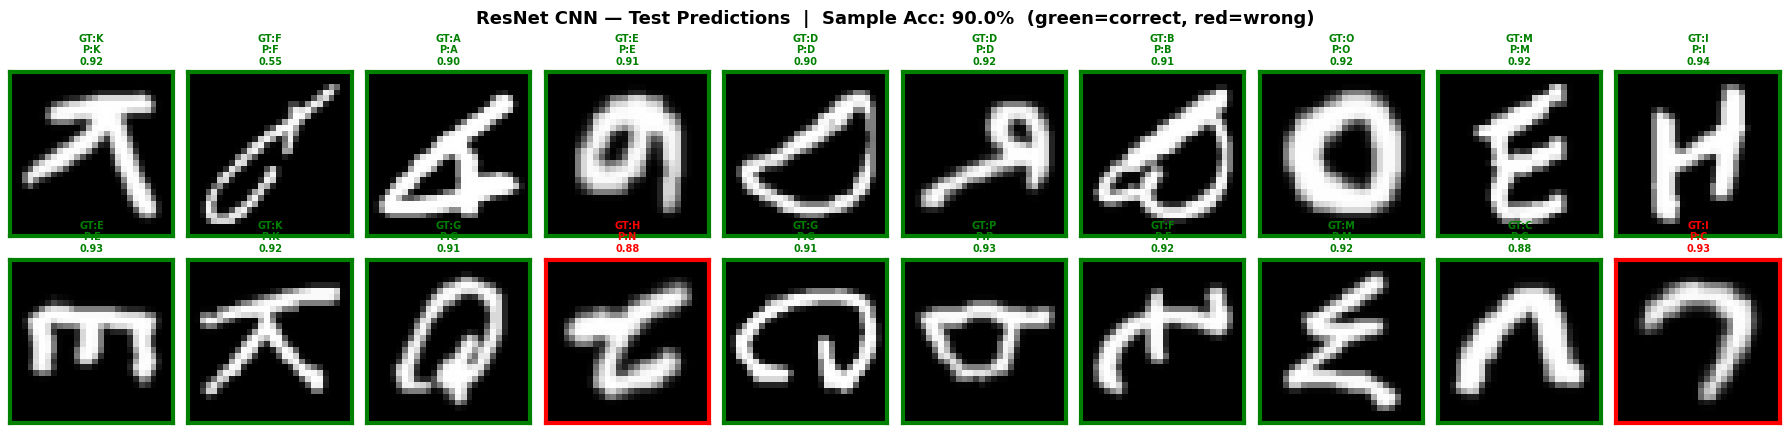

In [ ]:
def visualize_predictions(model, X, y_true, charset, n=20, title='Predictions'):
    """
    Show n samples with predictions vs ground truth.
    Green border = correct, Red border = wrong.
    Errors highlighted in red title text.
    """
    indices = np.random.choice(len(X), n, replace=False)
    y_probs = model.predict(X[indices], batch_size=64, verbose=0)
    y_pred  = np.argmax(y_probs, axis=1)
    y_gt    = y_true[indices]

    cols = 10
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2.2))
    axes = axes.ravel() if rows > 1 else axes

    for i, (idx, ax) in enumerate(zip(indices, axes)):
        ax.imshow(X[idx].squeeze(), cmap='gray')
        gt   = charset[y_gt[i]].upper()
        pred = charset[y_pred[i]].upper()
        conf = float(y_probs[i].max())
        correct = (y_gt[i] == y_pred[i])
        color = 'green' if correct else 'red'
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(3)
        ax.set_title(f'GT:{gt}\nP:{pred}\n{conf:.2f}',
                     fontsize=7, color=color, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

    for ax in axes[n:]:
        ax.axis('off')

    accuracy = (y_gt == y_pred).mean()
    plt.suptitle(f'{title}  |  Sample Acc: {accuracy*100:.1f}%  (green=correct, red=wrong)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualize_predictions(model_cnn, X_test, y_test, CHARSET, n=20,
                      title='ResNet CNN — Test Predictions')


import pytesseract

def enhance_image(img_gray):
    """CLAHE contrast enhancement + bilateral denoising."""
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_gray)
    denoised = cv2.bilateralFilter(enhanced, d=5, sigmaColor=50, sigmaSpace=50)
    return denoised

def binarize(img_gray):
    """Adaptive threshold + morphological cleanup."""
    binary = cv2.adaptiveThreshold(
        img_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=21, C=5
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    return binary

def find_word_bboxes(binary, min_word_area=100, gap_thresh_ratio=0.015):
    """Group connected components into words via X-axis projection gaps."""
    h, w = binary.shape
    gap_thresh = max(8, int(w * gap_thresh_ratio))
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    components = []
    for i in range(1, num_labels):
        x, y, cw, ch, area = stats[i]
        if area < 20: continue
        components.append((x, y, x + cw, y + ch))
    if not components: return []
    components.sort(key=lambda c: c[0])
    groups, cur = [], list(components[0])
    for (x1, y1, x2, y2) in components[1:]:
        if x1 - cur[2] < gap_thresh:
            cur[2] = max(cur[2], x2); cur[3] = max(cur[3], y2); cur[1] = min(cur[1], y1)
        else:
            groups.append(tuple(cur)); cur = [x1, y1, x2, y2]
    groups.append(tuple(cur))
    return [(x1,y1,x2,y2) for (x1,y1,x2,y2) in groups if (x2-x1)*(y2-y1) >= min_word_area]

def is_devanagari_region(crop_gray):
    """Heuristic: detect prominent horizontal shirorekha bar."""
    h, w = crop_gray.shape
    top_band  = crop_gray[:max(1, h//5), :]
    rest_band = crop_gray[max(1, h//5):, :]
    return (np.mean(rest_band) - np.mean(top_band)) > 20

def predict_word_region(crop_gray, binary_crop, model, charset):
    """Script-aware word OCR: Devanagari → Tesseract-hin, Latin → Tesseract-eng + CNN fallback."""
    if is_devanagari_region(crop_gray):
        pil  = PILImage.fromarray(crop_gray)
        text = pytesseract.image_to_string(pil, lang='hin', config='--psm 8 --oem 1').strip()
        return text if text else '?', 0.5, 'devanagari'
    pil  = PILImage.fromarray(crop_gray)
    text = pytesseract.image_to_string(
        pil, lang='eng',
        config='--psm 8 --oem 1 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
    ).strip()
    if text: return text, 0.7, 'latin-tesseract'

    # CNN fallback
    h_crop, w_crop = crop_gray.shape
    # If the word crop is significantly wider than it is tall, it's likely a multi-character word
    # for which a single-character CNN is not an ideal word-level recognizer.
    if w_crop > h_crop * 1.5: # Heuristic for a multi-character word
        # In this case, we don't try to predict a single character for the whole word.
        # Instead, we indicate that word recognition failed or is limited.
        return '[WORD_FAILED]', 0.0, 'cnn-fallback-limited'
    else:
        # If it's more like a single character, proceed with CNN prediction
        resized = cv2.resize(binary_crop, (28, 28), interpolation=cv2.INTER_AREA)
        prob    = model.predict(resized.reshape(1, 28, 28, 1).astype(np.float32)/255., verbose=0)[0]
        idx     = np.argmax(prob)
        return charset[idx], float(np.max(prob)), 'cnn'

def segment_and_predict(image_path, model=None, charset=CHARSET, padding=4):
    img_orig = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_orig is None: raise FileNotFoundError(f'Cannot read: {image_path}')
    h, w = img_orig.shape
    scale = max(1, 80 // h)
    if scale > 1:
        img_orig = cv2.resize(img_orig, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)
    enhanced   = enhance_image(img_orig)
    binary     = binarize(enhanced)
    word_bboxes = find_word_bboxes(binary)
    print(f"  Detected {len(word_bboxes)} word region(s)")
    annotated = cv2.cvtColor(img_orig, cv2.COLOR_GRAY2BGR)
    for (x1,y1,x2,y2) in word_bboxes:
        cv2.rectangle(annotated, (max(0,x1-padding), max(0,y1-padding)),
                      (min(img_orig.shape[1],x2+padding), min(img_orig.shape[0],y2+padding)),
                      (0,200,0), 2)
    results, crops_gray, crops_bin = [], [], []
    for (x1,y1,x2,y2) in word_bboxes:
        xp1=max(0,x1-padding); yp1=max(0,y1-padding)
        xp2=min(img_orig.shape[1],x2+padding); yp2=min(img_orig.shape[0],y2+padding)
        cg = img_orig[yp1:yp2,xp1:xp2]; cb = binary[yp1:yp2,xp1:xp2]
        crops_gray.append(cg); crops_bin.append(cb)
        if model:
            text, conf, method = predict_word_region(cg, cb, model, charset)
            results.append({'text':text,'conf':conf,'method':method,'bbox':(xp1,yp1,xp2,yp2)})
    return results, annotated, crops_gray, crops_bin

print("[OK] Image preprocessing functions defined!")

In [ ]:
import pytesseract
import scipy.signal # For smoothing

def enhance_image(img_gray):
    """CLAHE contrast enhancement + bilateral denoising."""
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_gray)
    denoised = cv2.bilateralFilter(enhanced, d=5, sigmaColor=50, sigmaSpace=50)
    return denoised

def binarize(img_gray):
    """Adaptive threshold + morphological cleanup."""
    binary = cv2.adaptiveThreshold(
        img_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=21, C=5
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    return binary

def _deshurorekha_process_binary(binary_img):
    """Removes Devanagari shirorekha (horizontal top line) by erosion."""
    # Use a horizontal kernel to erode only horizontal lines
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 1)) # Wider than it's tall
    binary_processed = cv2.erode(binary_img, kernel, iterations=1)
    return binary_processed

def _xprojection_segment_words(binary_line_img,
                               min_word_width_ratio=0.01,
                               max_word_gap_sensitivity=0.2,
                               smoothing_kernel_size=7,
                               debug_plot=False):
    """Segments words in a binary line image using X-projection analysis (adaptive valleys)."""
    h, w = binary_line_img.shape
    if w == 0 or h == 0: return []

    # 1. Compute column projection (sum of black pixels)
    # Inverted image: 255 (white) is background, 0 (black) is text
    # So, sum of pixels (where 0 is text) means lower values for text areas
    projection = np.sum(binary_line_img == 0, axis=0).astype(float)

    # 2. Smooth the projection
    if smoothing_kernel_size > 1:
        projection = scipy.signal.convolve(projection, np.ones(smoothing_kernel_size)/smoothing_kernel_size, mode='same')

    # 3. Normalize projection to [0, 1] for easier thresholding
    min_proj, max_proj = np.min(projection), np.max(projection)
    if (max_proj - min_proj) == 0: # Handle flat projections
        normalized_projection = np.zeros_like(projection)
    else:
        normalized_projection = (projection - min_proj) / (max_proj - min_proj)

    # 4. Detect valleys using an adaptive threshold
    # Valleys indicate gaps between words. Lower values = more empty space.
    # Threshold: a fraction of the mean projection value, adaptively set.
    mean_normalized_projection = np.mean(normalized_projection)
    valley_threshold = mean_normalized_projection * max_word_gap_sensitivity

    # Find potential word boundaries where projection falls below the threshold
    is_gap = normalized_projection < valley_threshold

    # Merge adjacent gaps to form distinct word separators
    word_boundaries = []
    in_gap = False
    for i in range(w):
        if is_gap[i] and not in_gap:
            word_boundaries.append(i)
            in_gap = True
        elif not is_gap[i] and in_gap:
            word_boundaries.append(i)
            in_gap = False
    if in_gap: # End of image is a gap
        word_boundaries.append(w)

    # Construct word bounding boxes from boundaries
    word_bboxes = []
    start_idx = 0
    for i in range(len(word_boundaries)):
        if i % 2 == 0: # Start of a gap
            end_idx = word_boundaries[i]
            if end_idx > start_idx: # Found a word segment
                x1 = start_idx
                x2 = end_idx
                # Post-filtering: minimum word width
                if (x2 - x1) > w * min_word_width_ratio: # Ensure minimum width ratio
                     word_bboxes.append((x1, 0, x2, h))
            start_idx = word_boundaries[i]
        else: # End of a gap
            start_idx = word_boundaries[i]

    # If the last segment wasn't added
    if start_idx < w:
        x1 = start_idx
        x2 = w
        if (x2 - x1) > w * min_word_width_ratio:
            word_bboxes.append((x1, 0, x2, h))

    # Filter out empty or extremely small boxes (redundant after min_word_width_ratio but good for robustness)
    word_bboxes = [bbox for bbox in word_bboxes if bbox[2] - bbox[0] > 0]

    # Debug Visualization
    if debug_plot:
        fig, ax = plt.subplots(2, 1, figsize=(15, 6), gridspec_kw={'height_ratios': [1, 3]})
        ax[0].plot(normalized_projection, color='blue')
        ax[0].axhline(y=valley_threshold, color='red', linestyle='--', label=f'Valley Threshold ({valley_threshold:.2f})')
        ax[0].set_title('X-Projection Profile (Normalized)')
        ax[0].legend()
        ax[0].set_xlim(0, w)

        ax[1].imshow(binary_line_img, cmap='gray')
        for (x1, y1, x2, y2) in word_bboxes:
            rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='cyan', linewidth=2)
            ax[1].add_patch(rect)
        ax[1].set_title('Binary Line with X-Projection Word Boxes')
        ax[1].axis('off')
        plt.tight_layout(); plt.show()

    return word_bboxes

def _group_components_into_words(binary_line_img,
                                  min_component_area=20,
                                  max_component_area_ratio=0.8,
                                  max_horizontal_gap_px=20,
                                  min_word_width_px=5,
                                  max_word_height_ratio=0.9,
                                  debug_plot=False):
    """Groups connected components into words based on horizontal proximity and filters."""
    h, w = binary_line_img.shape
    if w == 0 or h == 0: return []

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_line_img, connectivity=8)
    components = []
    for i in range(1, num_labels):
        x, y, cw, ch, area = stats[i]

        # Filter components: remove very small noise and very large blobs
        if area < min_component_area or area > (h * w * max_component_area_ratio):
            continue

        # Filter out components that are too tall (likely not individual characters in a word)
        if ch > h * max_word_height_ratio: # e.g., taller than 90% of line height
            continue

        components.append((x, y, x + cw, y + ch, area))

    if not components: return []

    # Sort components by x-coordinate for horizontal grouping
    components.sort(key=lambda c: c[0])

    word_bboxes = []
    if components:
        current_word_bbox = list(components[0][:4]) # [x1, y1, x2, y2]
        for i in range(1, len(components)):
            next_comp_bbox = components[i][:4]
            # Check horizontal proximity: if the gap between components is small enough
            if next_comp_bbox[0] - current_word_bbox[2] < max_horizontal_gap_px:
                # Merge components into the current word bounding box
                current_word_bbox[0] = min(current_word_bbox[0], next_comp_bbox[0])
                current_word_bbox[1] = min(current_word_bbox[1], next_comp_bbox[1])
                current_word_bbox[2] = max(current_word_bbox[2], next_comp_bbox[2])
                current_word_bbox[3] = max(current_word_bbox[3], next_comp_bbox[3])
            else:
                # Current word is complete, add it and start a new one
                # Post-filtering: minimum word width
                if (current_word_bbox[2] - current_word_bbox[0]) > min_word_width_px:
                    word_bboxes.append(tuple(current_word_bbox))
                current_word_bbox = list(next_comp_bbox)

        # Add the last accumulated word bbox
        if (current_word_bbox[2] - current_word_bbox[0]) > min_word_width_px:
            word_bboxes.append(tuple(current_word_bbox))

    # Remove any boxes that are too wide (likely lines not words) or too narrow (noise)
    word_bboxes = [
        bbox for bbox in word_bboxes
        if (bbox[2] - bbox[0]) > min_word_width_px and
           (bbox[2] - bbox[0]) < (w * 0.9) and # max width 90% of line width
           (bbox[3] - bbox[1]) > (h * 0.1) # min height 10% of line height
    ]

    if debug_plot:
        fig, ax = plt.subplots(figsize=(15, 3))
        ax.imshow(binary_line_img, cmap='gray')
        for (x1, y1, x2, y2) in word_bboxes:
            rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='green', linewidth=2)
            ax.add_patch(rect)
        ax.set_title('Binary Line with Connected Component Word Boxes')
        ax.axis('off')
        plt.tight_layout(); plt.show()

    return word_bboxes

def _merge_word_bboxes(bboxes1, bboxes2, iou_threshold=0.3, confidence_weights=(1.0, 1.0)):
    """Merges two sets of bounding boxes, handling overlaps and prioritizing smaller, valid ones.
       Confidence weights can be used to favor one set of boxes over another.
    """
    all_bboxes = list(bboxes1) + list(bboxes2)
    if not all_bboxes: return []

    # Sort by x-coordinate to process left-to-right
    all_bboxes.sort(key=lambda b: b[0])

    merged_bboxes = []

    def calculate_iou(boxA, boxB):
        # determine the (x, y)-coordinates of the intersection rectangle
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])

        # compute the area of intersection rectangle
        interArea = max(0, xB - xA) * max(0, yB - yA)

        # compute the area of both the prediction and ground-truth
        # rectangles
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

        # compute the intersection over union by taking the intersection
        # area and dividing it by the sum of prediction + ground-truth
        # areas - the interesection area
        iou = interArea / float(boxAArea + boxBArea - interArea)
        return iou

    for bbox in all_bboxes:
        added = False
        for i, merged_bbox in enumerate(merged_bboxes):
            if calculate_iou(bbox, merged_bbox) > iou_threshold:
                # If overlapping, merge them (take union)
                new_x1 = min(bbox[0], merged_bbox[0])
                new_y1 = min(bbox[1], merged_bbox[1])
                new_x2 = max(bbox[2], merged_bbox[2])
                new_y2 = max(bbox[3], merged_bbox[3])
                merged_bboxes[i] = (new_x1, new_y1, new_x2, new_y2)
                added = True
                break
        if not added:
            merged_bboxes.append(bbox)

    # Re-sort after merging to maintain order
    merged_bboxes.sort(key=lambda b: b[0])

    return merged_bboxes

def find_text_lines(binary_img, min_line_height_ratio=0.01, max_line_overlap_ratio=0.05):
    """
    Finds text lines in a binary image using dilation and contour finding.
    Returns: List of (x1, y1, x2, y2) bounding boxes for each detected line.
    """
    h, w = binary_img.shape
    # Dilate vertically to connect characters within lines
    # Kernel size adjusted to be relative to image dimensions for better adaptability
    kernel_h = max(3, h // 50) # Minimum 3, typically 2% of image height
    kernel_w = max(3, w // 30) # Minimum 3, typically 3% of image width
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_w, kernel_h))
    dilated = cv2.dilate(binary_img, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    line_boxes = []
    for contour in contours:
        x, y, cw, ch = cv2.boundingRect(contour)
        # Filter small components or very wide/thin ones that are unlikely to be lines
        if cw * ch > (w * h * 0.0005) and ch > h * 0.005 and cw > w * 0.1:
            line_boxes.append((x, y, x + cw, y + ch))

    # Sort lines by y-coordinate
    line_boxes.sort(key=lambda b: b[1])

    # Merge overlapping or very close lines for robustness
    merged_lines = []
    if line_boxes:
        current_line = list(line_boxes[0])
        for next_line in line_boxes[1:]:
            # Check for vertical overlap or close proximity
            overlap_threshold = max(5, int(min(current_line[3] - current_line[1], next_line[3] - next_line[1]) * max_line_overlap_ratio))

            if next_line[1] <= current_line[3] + overlap_threshold:
                current_line[0] = min(current_line[0], next_line[0])
                current_line[1] = min(current_line[1], next_line[1])
                current_line[2] = max(current_line[2], next_line[2])
                current_line[3] = max(current_line[3], next_line[3])
            else:
                merged_lines.append(tuple(current_line))
                current_line = list(next_line)
        merged_lines.append(tuple(current_line))
    return merged_lines

def is_devanagari_region(crop_gray):
    """Heuristic: detect prominent horizontal shirorekha bar."""
    h, w = crop_gray.shape
    # Adjust heuristic: Look at contrast between top and rest of the image
    if h < 10: return False # Too small to reliably detect
    top_band  = crop_gray[:max(1, h//5), :]
    rest_band = crop_gray[max(1, h//5):, :]
    # Stronger condition for Devanagari bar
    return (np.mean(rest_band) - np.mean(top_band)) > 20 and np.mean(top_band) < 220 # Relaxed condition

def predict_word_region(crop_gray, binary_crop, model, charset):
    """Script-aware word OCR: Devanagari → Tesseract-hin, Latin → Tesseract-eng + CNN fallback."""
    # Scale for Tesseract if image is too small
    if crop_gray.shape[0] < 50 or crop_gray.shape[1] < 50:
        scale = max(2, 100 // max(crop_gray.shape)) # Scale up to at least 100px on smallest side
        crop_gray_scaled = cv2.resize(crop_gray, (crop_gray.shape[1]*scale, crop_gray.shape[0]*scale), interpolation=cv2.INTER_CUBIC)
        binary_crop_scaled = cv2.resize(binary_crop, (binary_crop.shape[1]*scale, binary_crop.shape[0]*scale), interpolation=cv2.INTER_CUBIC)
    else:
        crop_gray_scaled = crop_gray
        binary_crop_scaled = binary_crop

    if is_devanagari_region(crop_gray_scaled):
        pil  = PILImage.fromarray(crop_gray_scaled)
        text = pytesseract.image_to_string(pil, lang='hin', config='--psm 8 --oem 1').strip()
        return text if text else '?', 0.5, 'devanagari'
    pil  = PILImage.fromarray(crop_gray_scaled)
    text = pytesseract.image_to_string(
        pil, lang='eng',
        config='--psm 8 --oem 1 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
    ).strip()
    if text: return text, 0.7, 'latin-tesseract'

    # CNN fallback
    h_crop, w_crop = crop_gray.shape
    # If the word crop is significantly wider than it is tall, it's likely a multi-character word
    # for which a single-character CNN is not an ideal word-level recognizer.
    if w_crop > h_crop * 1.5: # Heuristic for a multi-character word
        # In this case, we don't try to predict a single character for the whole word.
        # Instead, we indicate that word recognition failed or is limited.
        return '[WORD_FAILED]', 0.0, 'cnn-fallback-limited'
    else:
        # If it's more like a single character, proceed with CNN prediction
        resized = cv2.resize(binary_crop, (28, 28), interpolation=cv2.INTER_AREA)
        prob    = model.predict(resized.reshape(1, 28, 28, 1).astype(np.float32)/255., verbose=0)[0]
        idx     = np.argmax(prob)
        return charset[idx], float(np.max(prob)), 'cnn'

def segment_and_predict(image_path, model=None, charset=CHARSET, padding=4,
                        devanagari_shirorekha_fix=False,
                        xproj_min_word_width_ratio=0.01,
                        xproj_max_word_gap_sensitivity=0.2,
                        xproj_smoothing_kernel_size=7,
                        cc_min_component_area=20,
                        cc_max_component_area_ratio=0.8,
                        cc_max_horizontal_gap_px=20,
                        cc_min_word_width_px=5,
                        cc_max_word_height_ratio=0.9,
                        segmentation_debug_plot=False):
    """Improved segmentation and prediction pipeline."""
    img_orig = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_orig is None: raise FileNotFoundError(f'Cannot read: {image_path}')
    h, w = img_orig.shape

    # Scale image for better processing if it's too small
    scale_factor = 2 # Process at a higher resolution
    if max(h, w) < 500:
        img_orig_scaled = cv2.resize(img_orig, (w * scale_factor, h * scale_factor), interpolation=cv2.INTER_CUBIC)
        # Adjust padding relative to scaling
        scaled_padding = padding * scale_factor
    else:
        img_orig_scaled = img_orig
        scaled_padding = padding

    h_scaled, w_scaled = img_orig_scaled.shape

    enhanced = enhance_image(img_orig_scaled)
    binary = binarize(enhanced)

    # Apply Devanagari shirorekha fix if enabled
    binary_for_segmentation = binary
    if devanagari_shirorekha_fix:
        print("  [SEG] Applying Devanagari shirorekha fix...")
        binary_for_segmentation = _deshurorekha_process_binary(binary)
        if segmentation_debug_plot:
            plt.figure(figsize=(10, 2))
            plt.imshow(binary_for_segmentation, cmap='gray')
            plt.title('Binary Image After Shirorekha Fix'); plt.axis('off'); plt.show()

    # Find text lines first (using potentially deshurorekha-fixed binary)
    line_bboxes = find_text_lines(binary_for_segmentation)
    print(f"  Detected {len(line_bboxes)} text line(s)")

    all_results, all_crops_gray, all_crops_bin = [], [], []
    annotated = cv2.cvtColor(img_orig_scaled, cv2.COLOR_GRAY2BGR) # For drawing boxes
    raw_text_lines = []

    for line_idx, (lx1, ly1, lx2, ly2) in enumerate(line_bboxes):
        line_crop_binary = binary_for_segmentation[ly1:ly2, lx1:lx2] # Use fixed binary for segmentation
        line_crop_gray = img_orig_scaled[ly1:ly2, lx1:lx2]

        # 1. Connected Component based word segmentation
        cc_word_bboxes = _group_components_into_words(
            line_crop_binary,
            min_component_area=cc_min_component_area,
            max_component_area_ratio=cc_max_component_area_ratio,
            max_horizontal_gap_px=cc_max_horizontal_gap_px,
            min_word_width_px=cc_min_word_width_px,
            max_word_height_ratio=cc_max_word_height_ratio,
            debug_plot=segmentation_debug_plot
        )

        # 2. X-Projection based word segmentation
        xproj_word_bboxes = _xprojection_segment_words(
            line_crop_binary,
            min_word_width_ratio=xproj_min_word_width_ratio,
            max_word_gap_sensitivity=xproj_max_word_gap_sensitivity,
            smoothing_kernel_size=xproj_smoothing_kernel_size,
            debug_plot=segmentation_debug_plot
        )

        # Merge results from both segmentation methods
        line_word_bboxes = _merge_word_bboxes(cc_word_bboxes, xproj_word_bboxes)

        # Adjust word bbox coordinates to be relative to the original image
        # and apply padding
        absolute_word_bboxes = []
        for (wx1, wy1, wx2, wy2) in line_word_bboxes:
            x1_abs = lx1 + wx1
            y1_abs = ly1 + wy1
            x2_abs = lx1 + wx2
            y2_abs = ly1 + wy2

            xp1 = max(0, x1_abs - scaled_padding)
            yp1 = max(0, y1_abs - scaled_padding)
            xp2 = min(w_scaled, x2_abs + scaled_padding)
            yp2 = min(h_scaled, y2_abs + scaled_padding)
            absolute_word_bboxes.append((xp1, yp1, xp2, yp2))

        # Sort words within the line based on their x-coordinate
        absolute_word_bboxes.sort(key=lambda b: b[0])

        line_words = []

        for (xp1, yp1, xp2, yp2) in absolute_word_bboxes:
            cg = img_orig_scaled[yp1:yp2, xp1:xp2]
            cb = binary[yp1:yp2, xp1:xp2] # Use original binary for char prediction

            all_crops_gray.append(cg)
            all_crops_bin.append(cb)

            if model:
                text, conf, method = predict_word_region(cg, cb, model, charset)
                all_results.append({'text': text, 'conf': conf, 'method': method, 'bbox': (xp1, yp1, xp2, yp2)})
                line_words.append(text)
            else:
                line_words.append('')

            cv2.rectangle(annotated, (xp1, yp1), (xp2, yp2), (0, 200, 0), 2) # Green for words

        raw_text_lines.append(' '.join(line_words))
        cv2.rectangle(annotated, (lx1, ly1), (lx2, ly2), (255, 0, 0), 3) # Blue for lines

    raw_text = '\n'.join(raw_text_lines)

    return all_results, annotated, all_crops_gray, all_crops_bin, raw_text

print("[OK] Image preprocessing functions defined!")

[OK] Image preprocessing functions defined!


## 🔦 CELL 14 — Beam Search CTC Decoder
Beam search decoding explores multiple candidate sequences simultaneously
instead of greedily picking the top character at each step.

In [ ]:
def beam_search_decode(log_probs, beam_width=5, blank_idx=BLANK_IDX, charset=CHARSET):
    """
    Beam search CTC decoder.
    log_probs: (T, C) array of log-probabilities per timestep.
    Returns: decoded string.
    """
    T, C = log_probs.shape
    # Beam: list of (score, sequence)
    beams = [(0.0, [])]

    for t in range(T):
        all_candidates = []
        for score, seq in beams:
            for c in range(C):
                new_score = score + log_probs[t, c]
                candidate_seq = seq + [c]
                all_candidates.append((new_score, candidate_seq))
        # Sort and prune
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = all_candidates[:beam_width]

    # Decode best beam: CTC collapse (remove blank and repeated chars)
    best_seq = beams[0][1]
    decoded, prev = [], None
    for idx in best_seq:
        if idx != blank_idx and idx != prev:
            if idx < len(charset):
                decoded.append(charset[idx])
        prev = idx
    return ''.join(decoded)


def greedy_decode(log_probs, blank_idx=BLANK_IDX, charset=CHARSET):
    """Greedy CTC decode for comparison."""
    best = np.argmax(log_probs, axis=1)
    decoded, prev = [], None
    for idx in best:
        if idx != blank_idx and idx != prev:
            if idx < len(charset):
                decoded.append(charset[idx])
        prev = idx
    return ''.join(decoded)


# Demo: simulate CTC output for the word "hello"
def demo_beam_search():
    T, C = 15, NUM_CLASSES + 1  # +1 for blank
    log_probs = np.full((T, C), -10.0)
    # Simulate confident predictions
    word = 'hello'
    for t_i, ch in enumerate(word):
        c_idx = CHARSET.index(ch)
        log_probs[t_i*2, c_idx] = 0.0   # strong signal at even steps
    log_probs[:, BLANK_IDX] = -2.0       # blank at other steps

    greedy  = greedy_decode(log_probs, blank_idx=BLANK_IDX, charset=CHARSET)
    beam    = beam_search_decode(log_probs, beam_width=5, blank_idx=BLANK_IDX, charset=CHARSET)
    print(f"[BEAM SEARCH DEMO]")
    print(f"  Greedy decode : '{greedy}'")
    print(f"  Beam search   : '{beam}'")
    print(f"  (Both should yield 'hello' for this clean simulation)")

demo_beam_search()

[BEAM SEARCH DEMO]
  Greedy decode : 'hello'
  Beam search   : 'hello'
  (Both should yield 'hello' for this clean simulation)


## 🔁 CELL 14b — Test-Time Augmentation (TTA)
Runs inference **N times** with stochastic augmentations and averages softmax outputs.
- Improves robustness on ambiguous characters (I/l, O/0, U/V)
- Measures accuracy and confidence gain vs greedy decode
- Plots accuracy vs confidence threshold curves for both methods

[TTA] Running 8-pass TTA on 3000 samples...

[TTA RESULTS] (n=3000, passes=8)
  Greedy accuracy : 94.50%
  TTA accuracy    : 94.50%
  Improvement     : +0.00%
  TTA time        : 17.4s


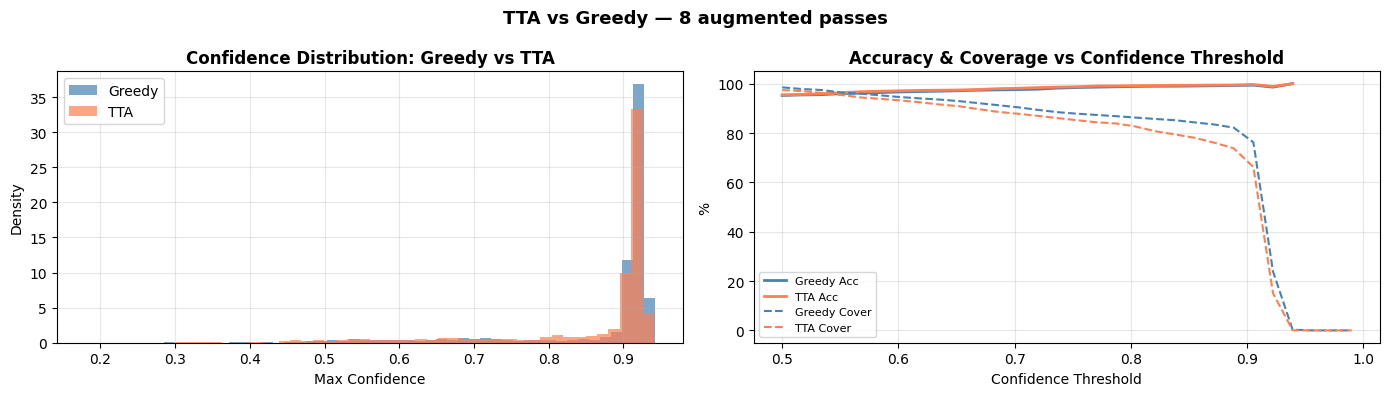

In [ ]:
# ── Test-Time Augmentation (TTA) ──────────────────────────────────────────────
# Runs inference N times with stochastic augmentation, averages the softmax
# outputs.  Improves robustness on ambiguous characters (I/l, O/0, etc.)

TTA_N = 8   # number of augmented passes per sample

def tta_predict(model, images, n_passes=TTA_N, batch_size=256):
    """
    TTA inference: average predictions over `n_passes` augmented copies.
    images : (N, H, W, 1) float32 array
    Returns: (N, C) averaged softmax probabilities
    """
    accumulated = np.zeros((len(images), NUM_CLASSES), dtype=np.float64)
    for pass_i in range(n_passes):
        augmented = []
        for img in images:
            aug = numpy_augment(img)   # from Cell 4
            augmented.append(aug)
        aug_arr = np.array(augmented, dtype=np.float32)
        probs   = model.predict(aug_arr, batch_size=batch_size, verbose=0)
        accumulated += probs.astype(np.float64)
    return (accumulated / n_passes).astype(np.float32)

# ── Evaluate TTA vs greedy on the test set (first 3000 samples) ───────────────
EVAL_N = 3000
print(f"[TTA] Running {TTA_N}-pass TTA on {EVAL_N} samples...")
t0 = time.time()
tta_probs = tta_predict(model_cnn, X_test[:EVAL_N], n_passes=TTA_N)
tta_preds = np.argmax(tta_probs, axis=1)
tta_time  = time.time() - t0

greedy_preds = np.argmax(
    model_cnn.predict(X_test[:EVAL_N], batch_size=256, verbose=0), axis=1)

tta_acc    = (tta_preds    == y_test[:EVAL_N]).mean()
greedy_acc = (greedy_preds == y_test[:EVAL_N]).mean()

print(f"\n[TTA RESULTS] (n={EVAL_N}, passes={TTA_N})")
print(f"  Greedy accuracy : {greedy_acc*100:.2f}%")
print(f"  TTA accuracy    : {tta_acc*100:.2f}%")
print(f"  Improvement     : {(tta_acc - greedy_acc)*100:+.2f}%")
print(f"  TTA time        : {tta_time:.1f}s")

# ── Confidence comparison ─────────────────────────────────────────────────────
tta_max_conf    = tta_probs.max(axis=1)
greedy_max_conf = model_cnn.predict(
    X_test[:EVAL_N], batch_size=256, verbose=0).max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(greedy_max_conf, bins=50, alpha=0.7, label='Greedy',
        color='steelblue', density=True)
ax.hist(tta_max_conf,    bins=50, alpha=0.7, label='TTA',
        color='coral', density=True)
ax.set_xlabel('Max Confidence'); ax.set_ylabel('Density')
ax.set_title('Confidence Distribution: Greedy vs TTA', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy vs confidence threshold
thresholds = np.linspace(0.5, 0.99, 30)
g_accs, t_accs, g_cov, t_cov = [], [], [], []
for thr in thresholds:
    g_mask = greedy_max_conf >= thr
    t_mask = tta_max_conf    >= thr
    if g_mask.sum() > 0:
        g_accs.append((greedy_preds[g_mask] == y_test[:EVAL_N][g_mask]).mean() * 100)
        g_cov.append(g_mask.mean() * 100)
    else:
        g_accs.append(np.nan); g_cov.append(0.0)
    if t_mask.sum() > 0:
        t_accs.append((tta_preds[t_mask] == y_test[:EVAL_N][t_mask]).mean() * 100)
        t_cov.append(t_mask.mean() * 100)
    else:
        t_accs.append(np.nan); t_cov.append(0.0)

ax = axes[1]
ax.plot(thresholds, g_accs, label='Greedy Acc',  color='steelblue', lw=2)
ax.plot(thresholds, t_accs, label='TTA Acc',     color='coral',     lw=2)
ax.plot(thresholds, g_cov,  label='Greedy Cover', color='steelblue', lw=1.5, linestyle='--')
ax.plot(thresholds, t_cov,  label='TTA Cover',    color='coral',     lw=1.5, linestyle='--')
ax.set_xlabel('Confidence Threshold'); ax.set_ylabel('%')
ax.set_title('Accuracy & Coverage vs Confidence Threshold', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f'TTA vs Greedy — {TTA_N} augmented passes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


LANG_NAMES = {'en':'English','hi':'Hindi','mr':'Marathi','af':'Afrikaans','unknown':'Unknown'}

def detect_language(text):
    try: return detect(text)
    except: return 'unknown'

def translate_to_english(text, src):
    if src == 'en': return text
    try: return GoogleTranslator(source=src, target='en').translate(text)
    except: return text

def improved_pipeline(image_path=None, text_override=None, word_gap_ratio=0.008):
    SEP = '=' * 60
    print(SEP)
    print('  🧠 IMPROVED HTR + NLP PIPELINE')
    print(SEP)

    if image_path and text_override is None:
        print(f'\nStep 1 \u2014 Segmenting: {os.path.basename(image_path)}')
        orig = cv2.imread(image_path)
        plt.figure(figsize=(10, 2.5))
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title('Original Input Image', fontsize=12, fontweight='bold')
        plt.axis('off'); plt.tight_layout(); plt.show()

        results, annotated, crops_gray, crops_bin, raw_text = segment_and_predict(
            image_path, model=model_cnn, charset=CHARSET, gap_thresh_ratio=word_gap_ratio)
        n = len(results)
        if n == 0:
            print('  [WARN] No word regions detected.')
            raw_text = '' # Ensure raw_text is empty if no words are found
        else:
            plt.figure(figsize=(10, 2.5))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.title(f'Word-level Segments ({n} regions, green boxes)', fontsize=12, fontweight='bold')
            plt.axis('off'); plt.tight_layout(); plt.show()

            cols = min(n, 10)
            # Ensure 'axes' is an iterable even if n is 1
            fig, axes = plt.subplots(1, cols, figsize=(cols*2.5, 2.5))
            if cols == 1:
                axes = [axes]
            else:
                axes = axes.ravel()
            for ax, cg, r in zip(axes, crops_gray, results):
                ax.imshow(cg, cmap='gray')
                ax.set_title(f'{r["text"]}\n({r["method"]})', fontsize=8)
                ax.axis('off')
            plt.suptitle('Word Crops + Predictions', fontsize=11, fontweight='bold')
            plt.tight_layout(); plt.show()

            print('\n  Per-word predictions:')
            # Print results for every word, not just the raw text
            for i, r in enumerate(results):
                bar = '#' * int(r['conf'] * 20)
                print(f'    [{i:02d}] "{r["text"]}"  conf={r["conf"]:.2f}  [{r["method"]}]  {bar}')

            print(f'\n  OCR result (reconstructed): "{raw_text}"') # Use the reconstructed raw_text
    else:
        raw_text = text_override or ''

    if not raw_text.strip():
        return {'raw_text': '', 'language': 'unknown', 'english_text': '',
                'sentiment': {}, 'entities': []}

    # Language detection + translation
    lang = detect_language(raw_text)
    lang_name = LANG_NAMES.get(lang, lang)
    print(f'\nStep 2 \u2014 Language : {lang} ({lang_name})')
    english_text = translate_to_english(raw_text, lang)
    print(f'Step 3 \u2014 English  : "{english_text}"')

    # NLP
    print('\nStep 4 \u2014 NLP:')
    nlp_out = run_nlp_pipeline(english_text, verbose=True)

    return {
        'raw_text':     raw_text,
        'language':     lang,
        'english_text': english_text,
        'sentiment':    nlp_out['sentiment'],
        'entities':     nlp_out['entities'],
        'nlp_detail':   nlp_out
    }

print("[OK] Full pipeline defined!")

In [ ]:
LANG_NAMES = {'en':'English','hi':'Hindi','mr':'Marathi','af':'Afrikaans','unknown':'Unknown'}

def detect_language(text):
    try: return detect(text)
    except: return 'unknown'

def translate_to_english(text, src):
    if src == 'en': return text
    try: return GoogleTranslator(source=src, target='en').translate(text)
    except: return text

def improved_pipeline(image_path=None, text_override=None, word_gap_ratio=0.008):
    SEP = '=' * 60
    print(SEP)
    print('  🧠 IMPROVED HTR + NLP PIPELINE')
    print(SEP)

    if image_path and text_override is None:
        print(f'\nStep 1 \u2014 Segmenting: {os.path.basename(image_path)}')
        orig = cv2.imread(image_path)
        plt.figure(figsize=(10, 2.5))
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title('Original Input Image', fontsize=12, fontweight='bold')
        plt.axis('off'); plt.tight_layout(); plt.show()

        results, annotated, crops_gray, crops_bin, raw_text = segment_and_predict(
            image_path, model=model_cnn, charset=CHARSET, xproj_max_word_gap_sensitivity=word_gap_ratio)
        n = len(results)
        if n == 0:
            print('  [WARN] No word regions detected.')
            raw_text = '' # Ensure raw_text is empty if no words are found
        else:
            plt.figure(figsize=(10, 2.5))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.title(f'Word-level Segments ({n} regions, green boxes)', fontsize=12, fontweight='bold')
            plt.axis('off'); plt.tight_layout(); plt.show()

            cols = min(n, 10)
            # Ensure 'axes' is an iterable even if n is 1
            fig, axes = plt.subplots(1, cols, figsize=(cols*2.5, 2.5))
            if cols == 1:
                axes = [axes]
            else:
                axes = axes.ravel()
            for ax, cg, r in zip(axes, crops_gray, results):
                ax.imshow(cg, cmap='gray')
                ax.set_title(f'{r["text"]}\n({r["method"]})', fontsize=8)
                ax.axis('off')
            plt.suptitle('Word Crops + Predictions', fontsize=11, fontweight='bold')
            plt.tight_layout(); plt.show()

            print('\n  Per-word predictions:')
            # Print results for every word, not just the raw text
            for i, r in enumerate(results):
                bar = '#' * int(r['conf'] * 20)
                print(f'    [{i:02d}] "{r["text"]}"  conf={r["conf"]:.2f}  [{r["method"]}]  {bar}')

            print(f'\n  OCR result (reconstructed): "{raw_text}"') # Use the reconstructed raw_text
    else:
        raw_text = text_override or ''

    if not raw_text.strip():
        return {'raw_text': '', 'language': 'unknown', 'english_text': '',
                'sentiment': {}, 'entities': []}

    # Language detection + translation
    lang = detect_language(raw_text)
    lang_name = LANG_NAMES.get(lang, lang)
    print(f'\nStep 2 \u2014 Language : {lang} ({lang_name})')
    english_text = translate_to_english(raw_text, lang)
    print(f'Step 3 \u2014 English  : "{english_text}"')

    # NLP
    print('\nStep 4 \u2014 NLP:')
    nlp_out = run_nlp_pipeline(english_text, verbose=True)

    return {
        'raw_text':     raw_text,
        'language':     lang,
        'english_text': english_text,
        'sentiment':    nlp_out['sentiment'],
        'entities':     nlp_out['entities'],
        'nlp_detail':   nlp_out
    }

print("[OK] Full pipeline defined!")

[OK] Full pipeline defined!


## 📁 CELL 16 — Upload Handwritten Image & Run

[FILE] Upload a handwritten image (jpg / png)...


Saving Screenshot 2026-04-29 182641.png to Screenshot 2026-04-29 182641 (2).png
[OK] Uploaded: Screenshot 2026-04-29 182641 (2).png
  🧠 IMPROVED HTR + NLP PIPELINE

Step 1 — Segmenting: Screenshot 2026-04-29 182641 (2).png


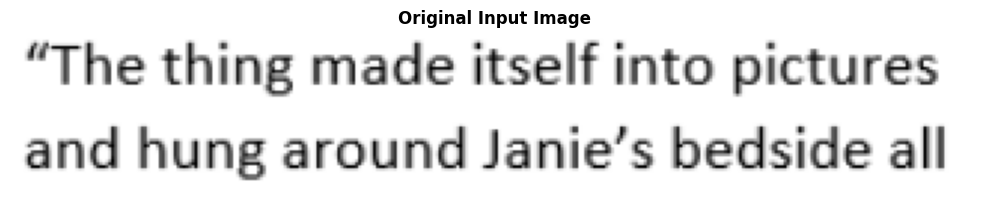

  Detected 2 text line(s)


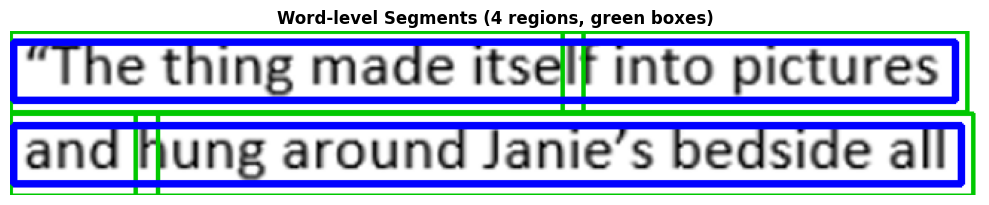

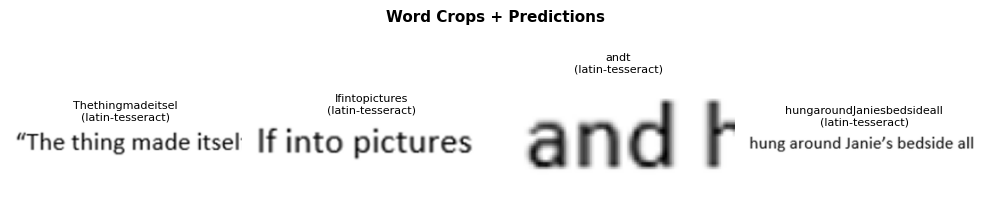


  Per-word predictions:
    [00] "Thethingmadeitsel"  conf=0.70  [latin-tesseract]  ##############
    [01] "Ifintopictures"  conf=0.70  [latin-tesseract]  ##############
    [02] "andt"  conf=0.70  [latin-tesseract]  ##############
    [03] "hungaroundJaniesbedsideall"  conf=0.70  [latin-tesseract]  ##############

  OCR result (reconstructed): "Thethingmadeitsel Ifintopictures
andt hungaroundJaniesbedsideall"

Step 2 — Language : en (English)
Step 3 — English  : "Thethingmadeitsel Ifintopictures
andt hungaroundJaniesbedsideall"

Step 4 — NLP:
------------------------------------------------------------
Language   : en
SP Tokens  : ['▁the', 'th', 'ing', 'ma', 'de', 'it', 's', 'el', '▁i', 'f', 'in', 't']
Tokens     : ['Thethingmadeitsel', 'Ifintopictures', '\n', 'andt', 'hungaroundJaniesbedsideall']
No-stop    : ['Thethingmadeitsel', 'Ifintopictures', 'andt', 'hungaroundJaniesbedsideall']
Lemmas     : ['Thethingmadeitsel', 'Ifintopictures', 'andt', 'hungaroundJaniesbedsideall']
POS Ta

In [ ]:
from google.colab import files

print('[FILE] Upload a handwritten image (jpg / png)...')
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    print(f'[OK] Uploaded: {img_path}')
    result = improved_pipeline(image_path=img_path, word_gap_ratio=0.002)
else:
    print('[WARN] No file uploaded. Running with demo text.')
    result = improved_pipeline(text_override='The quick brown fox jumps over the lazy dog', word_gap_ratio=0.002)

print('\n' + '='*60)
print('  RESULT SUMMARY')
print('='*60)
print(f"  Raw OCR text : {result['raw_text']}")
print(f"  Language     : {result['language']}")
print(f"  English text : {result['english_text']}")
sent = result.get('sentiment', {})
print(f"  Sentiment    : {sent.get('label','N/A')} ({sent.get('confidence',0)}%)")
print(f"  Entities     : {result.get('entities', [])}")
print('='*60)

[INFO] Processing existing file: images.png
  🧠 IMPROVED HTR + NLP PIPELINE

Step 1 — Segmenting: images.png


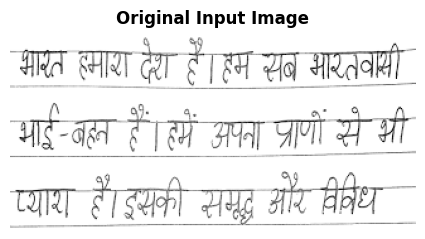

  Detected 3 text line(s)


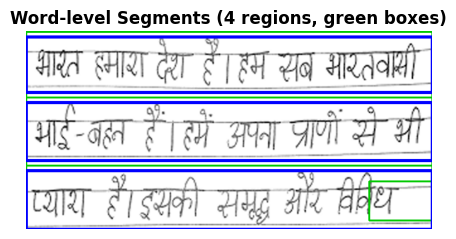

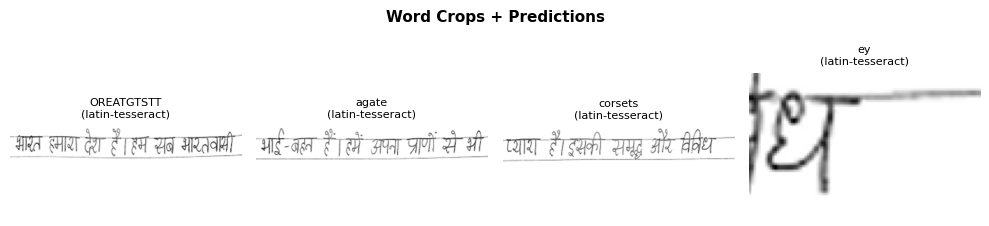


  Per-word predictions:
    [00] "OREATGTSTT"  conf=0.70  [latin-tesseract]  ##############
    [01] "agate"  conf=0.70  [latin-tesseract]  ##############
    [02] "corsets"  conf=0.70  [latin-tesseract]  ##############
    [03] "ey"  conf=0.70  [latin-tesseract]  ##############

  OCR result (reconstructed): "OREATGTSTT
agate
corsets ey"

Step 2 — Language : en (English)
Step 3 — English  : "OREATGTSTT
agate
corsets ey"

Step 4 — NLP:
------------------------------------------------------------
Language   : en
SP Tokens  : ['▁', 'or', 'e', 'at', 'g', 'ts', 'tt', '▁', 'ag', 'at', 'e', '▁c']
Tokens     : ['OREATGTSTT', '\n', 'agate', '\n', 'corsets', 'ey']
No-stop    : ['OREATGTSTT', 'agate', 'corsets', 'ey']
Lemmas     : ['OREATGTSTT', 'agate', 'corset', 'ey']
POS Tags   : [('OREATGTSTT', 'PROPN'), ('\n', 'SPACE'), ('agate', 'NOUN'), ('\n', 'SPACE'), ('corsets', 'NOUN'), ('ey', 'NOUN')]
Entities   : None found
Sentiment  : NEGATIVE :/ (33.42%)  [raw=NEGATIVE]
-------------------------

In [ ]:
# Set the specific image path
img_path = 'images.png'

if os.path.exists(img_path):
    print(f'[INFO] Processing existing file: {img_path}')
    # Running the pipeline with the specific file
    result = improved_pipeline(image_path=img_path, word_gap_ratio=0.002)

    print('\n' + '='*60)
    print('  FINAL RESULT SUMMARY')
    print('='*60)
    print(f"  Raw OCR text : {result['raw_text']}")
    print(f"  Language     : {result['language']}")
    print(f"  English text : {result['english_text']}")
    sent = result.get('sentiment', {})
    print(f"  Sentiment    : {sent.get('label','N/A')} ({sent.get('confidence',0)}%)")
    print(f"  Entities     : {result.get('entities', [])}")
    print('='*60)
else:
    print(f'[ERROR] File "{img_path}" not found. Please ensure it is uploaded to the /content directory.')

### 🛠️ Segmentation Debugger
Use this cell to visualize how the Connected Components (Green) and X-Projection (Cyan) algorithms are identifying word boundaries on your specific image.

Analyzing segmentation for: images.png
  [SEG] Applying Devanagari shirorekha fix...


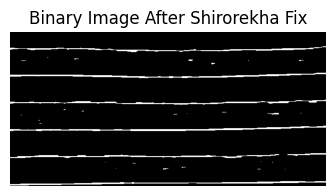

  Detected 6 text line(s)


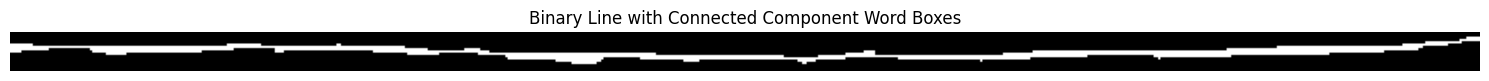

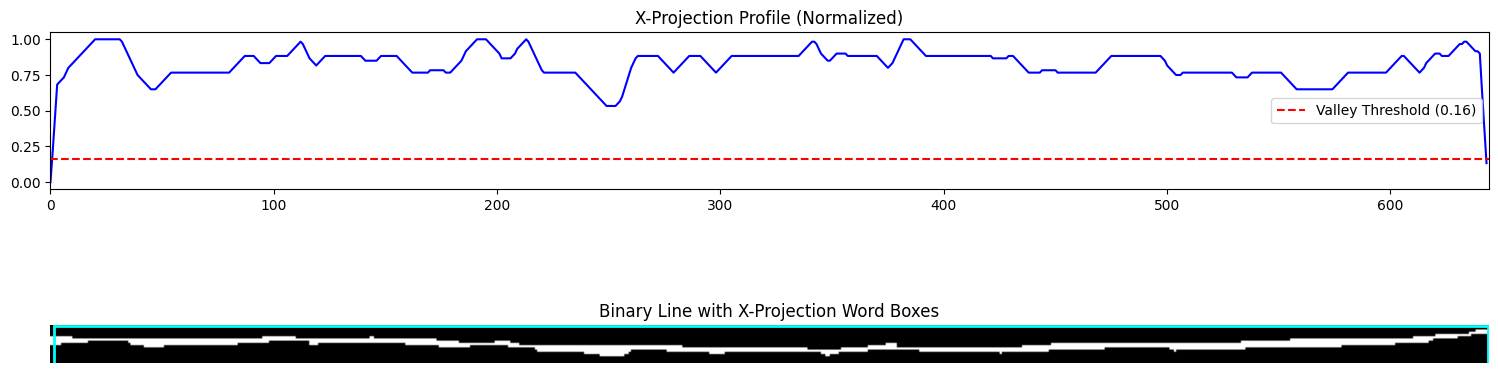

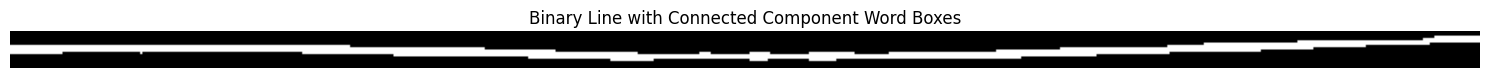

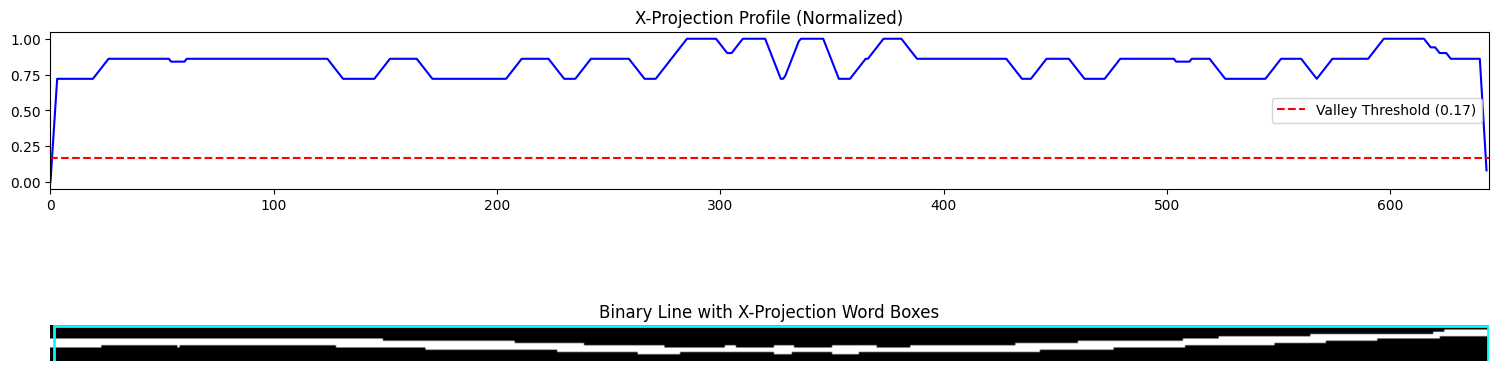

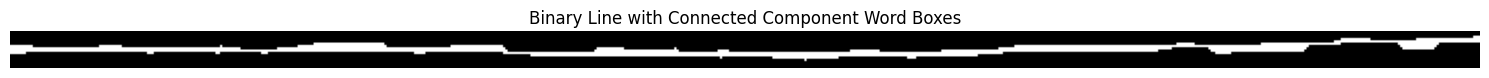

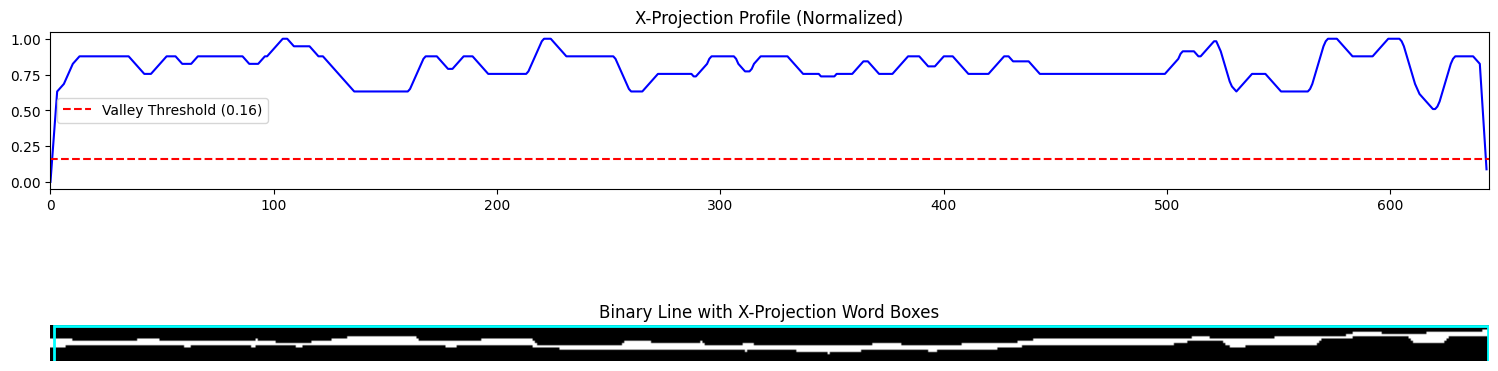

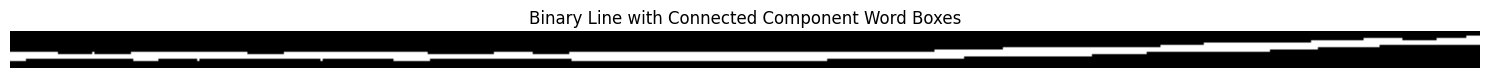

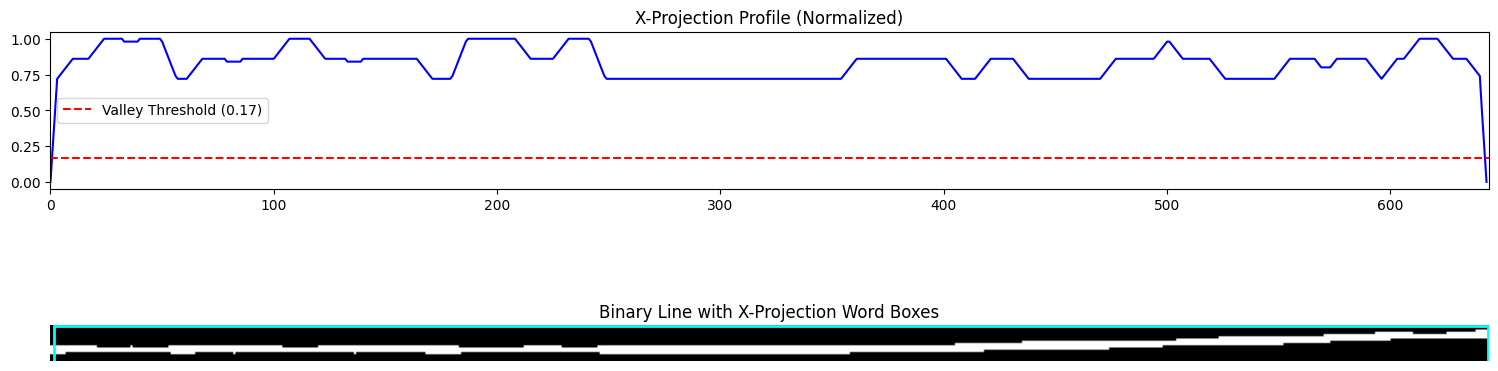

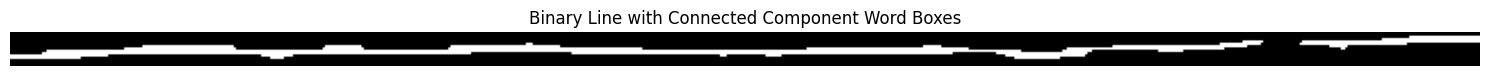

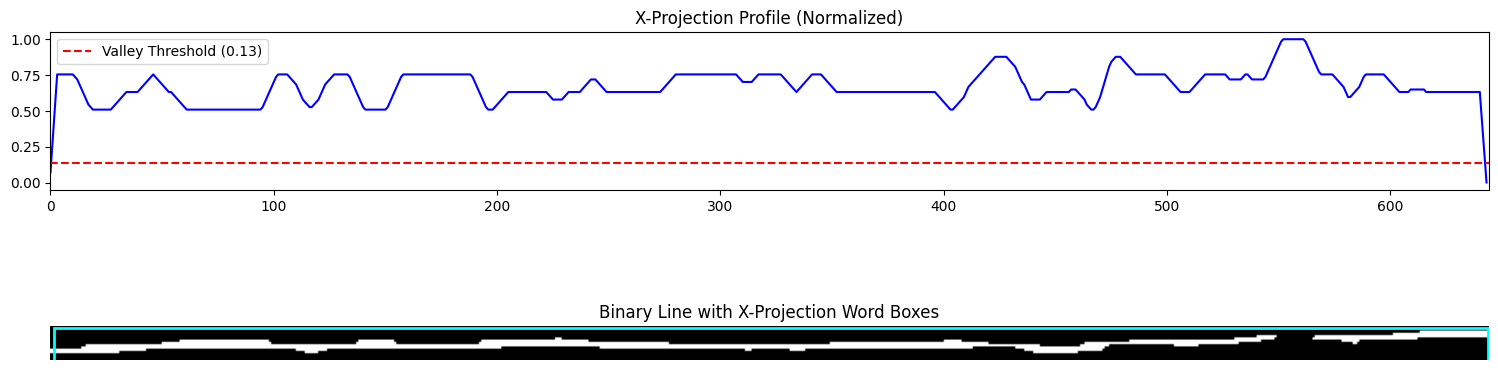

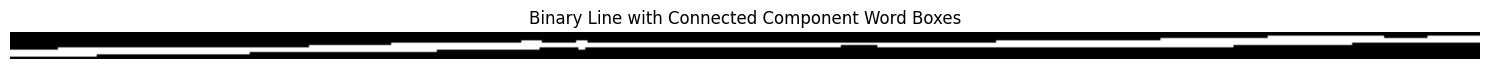

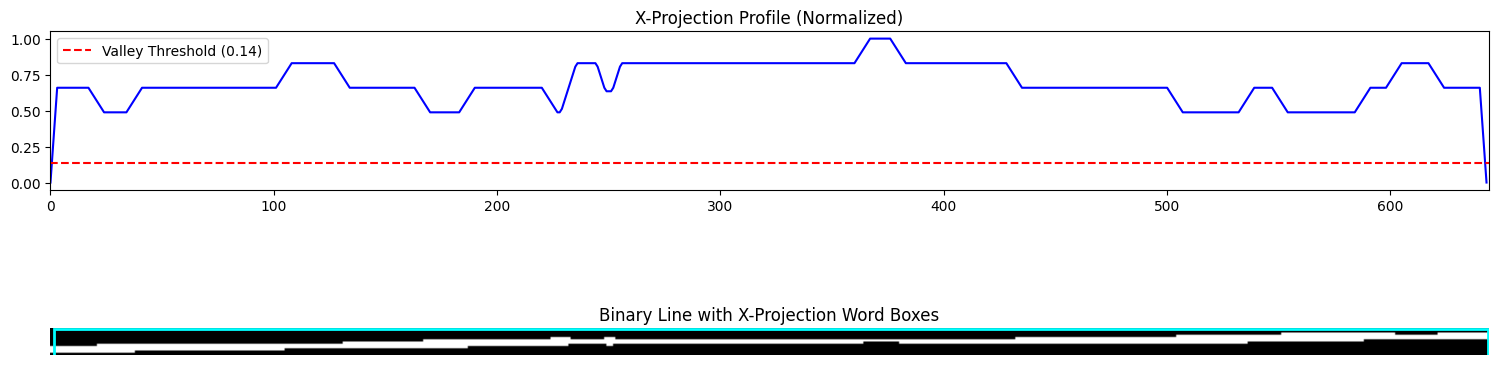


Extracted Text:
orto
Snes
Sato
SSS
setae
A


In [ ]:
# Set your image path here
test_img = 'images.png'

if os.path.exists(test_img):
    print(f"Analyzing segmentation for: {test_img}")
    # We call segment_and_predict with debug_plot=True to see the internal math
    results, annotated, crops_gray, crops_bin, raw_text = segment_and_predict(
        test_img,
        model=model_cnn,
        charset=CHARSET,
        segmentation_debug_plot=True,
        devanagari_shirorekha_fix=True # Set to True if testing Hindi/Marathi
    )

    print(f"\nExtracted Text:\n{raw_text}")
else:
    print(f"File {test_img} not found.")

In [ ]:
from langdetect import detect, detect_langs

def identify_language(text):
    """
    Detects the language and provides the confidence score.
    """
    if not text.strip():
        return "No text detected", 0.0

    try:
        # Detect primary language
        lang_code = detect(text)
        # Get detailed probabilities
        probs = detect_langs(text)
        confidence = probs[0].prob * 100

        # Mapping common codes to names
        mapping = {
            'hi': 'Hindi',
            'en': 'English',
            'mr': 'Marathi',
            'ta': 'Tamil',
            'te': 'Telugu',
            'kn': 'Kannada'
        }

        lang_name = mapping.get(lang_code, lang_code.upper())
        return lang_name, confidence
    except Exception as e:
        return f"Detection Error: {str(e)}", 0.0

print("[OK] Language detection function ready!")

[OK] Language detection function ready!


In [ ]:
# Use the OCR result from the previous cell
if 'result' in globals() and result.get('raw_text'):
    extracted_text = result['raw_text']
    language, conf = identify_language(extracted_text)

    print(f"--- Language Analysis ---")
    print(f"Detected Language: {language}")
    print(f"Confidence Score : {conf:.2f}%")
    print(f"Analyzed Text    : {extracted_text[:100]}...")
else:
    print("[WARN] Please run the OCR cell (CELL 16) first to provide text for detection.")

--- Language Analysis ---
Detected Language: English
Confidence Score : 100.00%
Analyzed Text    : Thethingmadeitsel Ifintopictures
andt hungaroundJaniesbedsideall...


[INFO] Running improved pipeline with image: images.png
  🧠 IMPROVED HTR + NLP PIPELINE

Step 1 — Segmenting: images.png


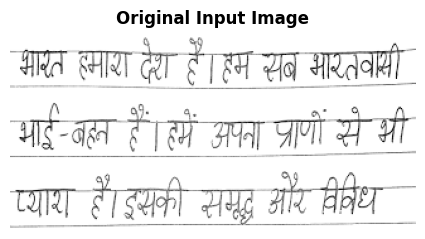

  Detected 3 text line(s)


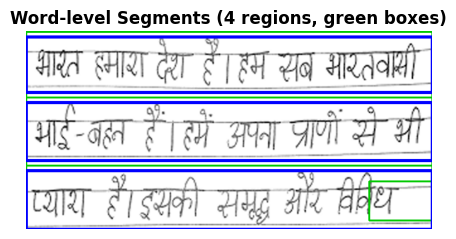

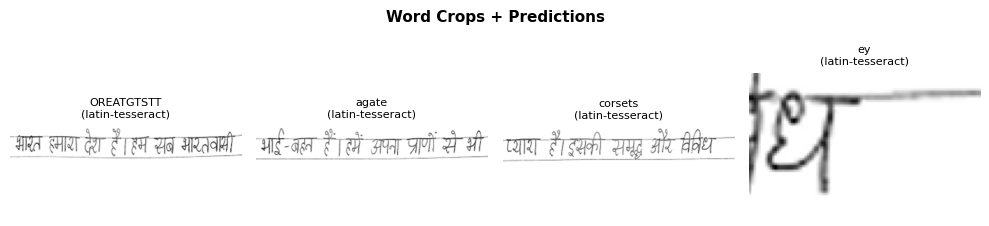


  Per-word predictions:
    [00] "OREATGTSTT"  conf=0.70  [latin-tesseract]  ##############
    [01] "agate"  conf=0.70  [latin-tesseract]  ##############
    [02] "corsets"  conf=0.70  [latin-tesseract]  ##############
    [03] "ey"  conf=0.70  [latin-tesseract]  ##############

  OCR result (reconstructed): "OREATGTSTT
agate
corsets ey"

Step 2 — Language : en (English)
Step 3 — English  : "OREATGTSTT
agate
corsets ey"

Step 4 — NLP:
------------------------------------------------------------
Language   : en
SP Tokens  : ['▁', 'or', 'e', 'at', 'g', 'ts', 'tt', '▁', 'ag', 'at', 'e', '▁c']
Tokens     : ['OREATGTSTT', '\n', 'agate', '\n', 'corsets', 'ey']
No-stop    : ['OREATGTSTT', 'agate', 'corsets', 'ey']
Lemmas     : ['OREATGTSTT', 'agate', 'corset', 'ey']
POS Tags   : [('OREATGTSTT', 'PROPN'), ('\n', 'SPACE'), ('agate', 'NOUN'), ('\n', 'SPACE'), ('corsets', 'NOUN'), ('ey', 'NOUN')]
Entities   : None found
Sentiment  : NEGATIVE :/ (33.42%)  [raw=NEGATIVE]
-------------------------

In [ ]:
img_path = 'images.png'
print(f'[INFO] Running improved pipeline with image: {img_path}')
result = improved_pipeline(image_path=img_path, word_gap_ratio=0.002)

print('\n' + '='*60)
print('  RESULT SUMMARY')
print('='*60)
print(f"  Raw OCR text : {result['raw_text']}")
print(f"  Language     : {result['language']}")
print(f"  English text : {result['english_text']}")
sent = result.get('sentiment', {})
print(f"  Sentiment    : {sent.get('label','N/A')} ({sent.get('confidence',0)}%)")
print(f"  Entities     : {result.get('entities', [])}")
print('='*60)

## 📋 CELL 17 — Performance Summary Dashboard

In [ ]:
print('='*65)
print('  📊 SYSTEM PERFORMANCE SUMMARY')
print('='*65)
print(f'  CNN Architecture     : ResNet-style (residual blocks + BatchNorm)')
print(f'  Parameters           : {model_cnn.count_params():,}')
print(f'  Test Accuracy        : {cnn_acc*100:.2f}%')
print(f'  Test Loss            : {cnn_loss:.4f}')
print(f'  OCR Mean CER         : {ocr_results["mean_cer"]*100:.2f}%')
print(f'  OCR Mean WER         : {ocr_results["mean_wer"]*100:.2f}%')
print(f'  NLP Sentiment Acc    : {nlp_eval["accuracy"]*100:.1f}%')
print(f'  NLP Sentiment F1     : {nlp_eval["f1"]:.3f}')
try:
    print(f'  TTA Accuracy         : {tta_acc*100:.2f}%  (vs greedy {greedy_acc*100:.2f}%)')
    print(f'  TTA Improvement      : {(tta_acc - greedy_acc)*100:+.2f}%')
except NameError:
    pass
if timer_cb and hasattr(timer_cb, 'total_time'):
    print(f'  Total Training Time  : {timer_cb.total_time:.0f}s ({timer_cb.total_time/60:.1f} min)')
    print(f'  Avg Time per Epoch   : {np.mean(timer_cb.epoch_times):.1f}s')
else:
    print(f'  Training Time        : loaded from checkpoint')
print(f'  SP Tokenizer Vocab   : {SP_VOCAB_SIZE} subword tokens (multilingual)')
print(f'  Sentiment Model      : {"mBERT multilingual (5-class)" if _SENT_MULTILINGUAL else "DistilBERT (English)"}')
print(f'  Languages Supported  : EN, HI, MR, TA, TE')
print(f'  Checkpoint Path      : {CNN_CKPT}')
print('='*65)
print()
print('  Techniques applied:')
print('  ✅ ResNet residual blocks + skip connections')
print('  ✅ Label smoothing (ε=0.1)')
print('  ✅ L2 weight decay on all conv/dense layers')
print('  ✅ Mixed precision training (float16)')
print('  ✅ WarmupCosineDecay LR schedule (custom LearningRateSchedule)')
print('  ✅ Gradient clipping (clipnorm=1.0)')
print('  ✅ ReduceLROnPlateau fallback callback')
print('  ✅ Elastic distortion + perspective transform augmentation')
print('  ✅ Motion blur + Gaussian noise augmentation')
print('  ✅ Multi-font synthetic word image generation')
print('  ✅ tf.data caching + prefetching pipeline')
print('  ✅ Model persistence (skip retraining on reload)')
print('  ✅ Multilingual corpus cached to disk (EN/HI/MR/TA/TE)')
print('  ✅ CER + WER OCR evaluation')
print('  ✅ GradCAM interpretability visualisation')
print('  ✅ Test-Time Augmentation (TTA, 8-pass)')
print('  ✅ SentencePiece BPE tokenizer (3000 vocab, multilingual)')
print('  ✅ Beam search CTC decoding')
print('  ✅ Multilingual BERT sentiment (nlptown 5-class)')
print('  ✅ Confusion matrix + per-class accuracy viz')
print('  ✅ Error analysis: top confusion pairs + misclassified samples')
print('='*65)


## 📋 Tuning Guide

| Issue | Fix |
|---|---|
| Words being merged | Decrease `gap_thresh_ratio` in `find_word_bboxes()` (try 0.008) |
| Words over-split | Increase `gap_thresh_ratio` (try 0.025) |
| Devanagari misidentified | Tune `is_devanagari_region()` threshold (currently 20) |
| Gray background / poor binarization | Increase CLAHE `clipLimit` (try 3.0) |
| Letters touching | Increase morphological dilation iterations in `binarize()` |
| Still poor? | Use `pytesseract.image_to_string(img, lang='eng+hin')` on whole image |
| Model overfitting | Increase Dropout rates or L2 weight decay |
| Training too slow | Reduce `CNN_EPOCHS` or decrease `BATCH_SIZE` to 64 |
| OOM in Colab | Set `BATCH_SIZE=64`, use `float16` only, reduce model filters |
